# Graph-A2 论文 Table 1 复现汇报

**目的**：把已有真实结果找回并分层汇报，而不是把不同协议的数字混成一张“最好看”的表。

当前作者代码快照包含 80 个数据集-比例-方法条件，但其中 Graph-A2 使用了与目标协议不符的图参数。**主复现表因此完全剔除这 10 个 Graph-A2 条件**，只统计不受图参数影响的七个方法：共 **70/70 个条件、350/350 次下游训练**。训练过程中每 10 epochs 访问一次 test，并同时保存 final BA 与 best-test BA。本报告以作者 runner 的主字段 `balanced_accuracy`（第 1000 epoch 后的 final BA）为主结果；`best_balanced_accuracy` 只作为重复查看 test 的敏感性诊断。

必须区分两件事：**作者代码的主 `balanced_accuracy` 字段确实是 final epoch**；但现有论文文字只写训练 1000 epochs，没有独立说明 Table 1 究竟读取 final 还是 best。因此本报告采用可由代码直接证明的 final 口径，同时不把这一代码证据夸大成对论文制表脚本的证明。

Graph-A2 只使用 `global, k=50, H=2` 的证据。现有两层为：**Path/Blood、seed42、32/32 条**的 validation-checkpoint 严格测试，以及 **Path Graph-A2、5 seeds、final epoch** 的独立确认。其余三个数据集尚无同协议的 Graph-A2 完整结果，明确标记为缺失。

## 1. 一分钟讲清楚整个实验

1. 从完整训练集提取 UNI embedding，或从一个代理模型的训练轨迹计算难度分数。
2. 每个方法只从训练集选出 2% 或 5% 的图片，并冻结这些图片的 indices。
3. 只用选中的小子集，从零训练一个 ResNet-18 共 1000 epochs。
4. 在 test split 上计算每个类别的 recall，再对类别取平均，得到 balanced accuracy（BA）。
5. 与论文 Table 1 的 `mean +/- std` 比较。`Delta = reproduction mean - paper mean`，正值表示本次复现更高。

这意味着表中的数字不是“选样分数”，而是**选出的子集最终训练出来的分类器效果**。

- **ACC（普通准确率）**：全部测试图片中预测正确的比例；样本很多的类别影响更大。
- **BA（平衡准确率）**：先分别计算每个类别的召回率，再让所有类别等权平均；少数类不会被多数类淹没。论文 Table 1 报告的是 BA，因此复现差值 `Delta` 只用 BA 计算；ACC 作为下游效果补充证据单独列出。

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.18})

cwd = Path.cwd().resolve()
if (cwd / 'evidence').is_dir():
    REPORT_DIR = cwd
elif (cwd / 'reports' / 'table1_group_meeting' / 'evidence').is_dir():
    REPORT_DIR = cwd / 'reports' / 'table1_group_meeting'
else:
    raise FileNotFoundError('Run from this notebook directory or the workspace root.')

EVIDENCE = REPORT_DIR / 'evidence'
FIGURES = REPORT_DIR / 'figures'
CALCULATED = REPORT_DIR / 'calculated_tables'
FIGURES.mkdir(exist_ok=True)
CALCULATED.mkdir(exist_ok=True)
PROJECT_ROOT = REPORT_DIR.parents[1]

DATASET_ORDER = ['organsmnist', 'organamnist', 'pathmnist', 'tissuemnist', 'bloodmnist']
DATASET_LABEL = {
    'organsmnist': 'OrganS', 'organamnist': 'OrganA', 'pathmnist': 'Path',
    'tissuemnist': 'Tissue', 'bloodmnist': 'Blood'
}
METHOD_ORDER = ['random', 'el2n', 'forgetting', 'eva', 'facility', 'fps', 'herding', 'graph_a2']
MAIN_METHOD_ORDER = [method for method in METHOD_ORDER if method != 'graph_a2']
METHOD_LABEL = {
    'random': 'Random', 'el2n': 'EL2N', 'forgetting': 'Forgetting', 'eva': 'EVA',
    'facility': 'Facility', 'fps': 'FPS', 'herding': 'Herding', 'graph_a2': 'Graph-A2'
}

print('Notebook:', (REPORT_DIR / 'table1_reproduction_group_meeting.ipynb').resolve())
print('Evidence:', EVIDENCE.resolve())
print('Figures:', FIGURES.resolve())
print('Calculated tables:', CALCULATED.resolve())

Notebook: C:\Users\Administrator\Documents\ChatGPT\New project\reports\table1_group_meeting\table1_reproduction_group_meeting.ipynb
Evidence: C:\Users\Administrator\Documents\ChatGPT\New project\reports\table1_group_meeting\evidence
Figures: C:\Users\Administrator\Documents\ChatGPT\New project\reports\table1_group_meeting\figures
Calculated tables: C:\Users\Administrator\Documents\ChatGPT\New project\reports\table1_group_meeting\calculated_tables


## 2. 证据路径与完整性

下面列出的本地文件都是从 HPC 真实产物复制的离线快照。SHA-256 在运行 Notebook 时重新计算。远端原始目录保留在表中，方便回到 Slurm 结果逐项审计。

In [2]:
REMOTE_PUBLIC = '/project/PROJECT_ROOT/USER/_archive_fork_20260830/graph_bench/table1_reproduction'
REMOTE_STRICT = '/project/PROJECT_ROOT/USER/_archive_fork_20260830/table1_strict_repro/table1_reproduction'

evidence_rows = [
    ('论文 Table 1 人工转录', EVIDENCE / 'paper_table1_transcribed.csv',
     r'C:/Users/Administrator/.codex/attachments/17423b8c-d2f6-4531-bd99-a0ba6701dc51/pasted-text.txt'),
    ('最终 394-run 汇总（Graph-A2 不纳入主表）', EVIDENCE / 'public_k10_394run_per_condition_mean_std.csv',
     REMOTE_PUBLIC + '/summary_k10_394run/per_condition_mean_std.csv'),
    ('最终表格快照（best-test 诊断，仅用于追溯）', EVIDENCE / 'public_k10_394run_table1_reproduction.md',
     REMOTE_PUBLIC + '/summary_k10_394run/table1_reproduction.md'),
    ('最终原始结果计数', EVIDENCE / 'public_k10_394run_raw_result_count.json',
     REMOTE_PUBLIC + '/summary_k10_394run/raw_result_count.json'),
    ('A 层缺口补跑 sacct 证据', EVIDENCE / 'missing_k10_sacct_29238_29243.txt',
     REMOTE_PUBLIC + '/logs + sacct jobs 29238--29243'),
    ('公开协议选样配置', EVIDENCE / 'public_k10_job1_config.json',
     REMOTE_PUBLIC + '/configs/job1_table1.json'),
    ('公开协议训练配置', EVIDENCE / 'public_k10_job2_config.json',
     REMOTE_PUBLIC + '/configs/job2_table1.json'),
    ('A 层实际选样 Slurm', EVIDENCE / 'layer_a_job1_select_array.slurm',
     REMOTE_PUBLIC + '/slurm/job1_select_array.slurm'),
    ('A 层实际训练 Slurm', EVIDENCE / 'layer_a_job2_downstream_array.slurm',
     REMOTE_PUBLIC + '/slurm/job2_downstream_array.slurm'),
    ('作者代码文件哈希', EVIDENCE / 'official_vendor_manifest.json',
     REMOTE_PUBLIC + '/table1_reproduction/vendor/official_manifest.json'),
    ('k=50 Path/Blood 严格结果', EVIDENCE / 'strict_k50_path_blood_seed42.json',
     REMOTE_STRICT + '/outputs/job2_path_blood_single_seed_valckpt/**/test_result.json'),
    ('B 层实际选样配置', EVIDENCE / 'strict_job1_path_blood_pilot.json',
     REMOTE_STRICT + '/configs/job1_path_blood_pilot.json'),
    ('B 层实际训练配置', EVIDENCE / 'strict_job2_path_blood_single_seed.json',
     REMOTE_STRICT + '/configs/job2_path_blood_single_seed.json'),
    ('B 层实际选样 Slurm', EVIDENCE / 'strict_job1_path_blood_pilot.slurm',
     REMOTE_STRICT + '/slurm/job1_path_blood_pilot.slurm'),
    ('B 层实际训练 Slurm', EVIDENCE / 'strict_job2_path_blood_single_seed.slurm',
     REMOTE_STRICT + '/slurm/job2_path_blood_single_seed.slurm'),
    ('五数据集规模与类别配置', PROJECT_ROOT / 'table1_reproduction' / 'configs' / 'datasets_server_3090.json',
     'table1_reproduction/configs/datasets_server_3090.json'),
    ('k=50 Path Graph-A2 5-seed 结果', PROJECT_ROOT / 'graph-a2-path-seed42-validation' / 'reports' / 'weekly_results_snapshot' / 'path_graph_a2_multiseed.csv',
     '/project/PROJECT_ROOT/USER/graph_a2_path_seed42_validation/results/path_multiseed_confirmatory/graph_a2_k50_h2/results.csv'),
    ('k=50 Path Graph-A2 Slurm 配置', PROJECT_ROOT / 'graph-a2-path-seed42-validation' / 'hpc' / 'path_multiseed_graph_a2.slurm',
     '/project/PROJECT_ROOT/USER/graph_a2_path_seed42_validation/hpc/path_multiseed_graph_a2.slurm'),
]

def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

evidence_df = pd.DataFrame(evidence_rows, columns=['evidence', 'local_path', 'remote_or_source_path'])
evidence_df['exists'] = evidence_df.local_path.map(Path.exists)
evidence_df['sha256'] = evidence_df.local_path.map(lambda p: sha256_file(p) if p.exists() else None)
assert evidence_df.exists.all(), evidence_df.loc[~evidence_df.exists]
display(evidence_df)

,evidence,local_path,remote_or_source_path,exists,sha256
0,论文 Table 1 人工转录,C:\Users\Administrator\Documents\ChatGPT\New p...,C:/Users/Administrator/.codex/attachments/1742...,True,06e7cf8bcfe478957b2c4c0a80db354ec1d4f6739ef0a3...
1,最终 394-run 汇总（Graph-A2 不纳入主表）,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,485442f63bf0a315a510817548ea58eb3fdadfad1c80b7...
2,最终表格快照（best-test 诊断，仅用于追溯）,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,16f16396143eba1535c3f79abe759b8f89e63e1a25220b...
3,最终原始结果计数,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,fc0426ce2b75631c1ac3e837df1446968220bc0dfb72ba...
4,A 层缺口补跑 sacct 证据,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,53bb6ae97587025638810c3319e702a6e5a46d1d292acc...
5,公开协议选样配置,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,918412000d880aecf11bed80b0bf0d4db9f36ff5bf5237...
6,公开协议训练配置,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,4f8360a022540b420a9e26e68b3acff35acfa28bd20e02...
7,A 层实际选样 Slurm,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,82cc34670949bbf99418b1c0df94e4384e687e0a17df3e...
8,A 层实际训练 Slurm,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,80865f75e6b917e38c810285e3719337cc8c7b4036de09...
9,作者代码文件哈希,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True,086f6a46e786084aca6c8b7db8ae4b529b2809acf3a866...


## 3. 协议分层：哪些数字能放在一起

| 层级 | 范围 | Graph-A2 图参数 | 训练与 test 使用 | 适合回答什么 |
|---|---|---|---|---|
| A. 七种基线的作者代码快照 | 5 数据集 x 2 ratio x 7 方法，350/350 runs | 不涉及 Graph-A2 图参数 | 1000 epochs；test 每 10 epochs 评估；主表取 final，best 仅作诊断 | “七种基线按作者 runner 的 final 字段能复现到什么程度？” |
| B. `k=50` 严格 pilot | Path/Blood x 2 ratio x 8 方法，seed42 | Graph-A2 为 global, `k=50`, `H=2` | validation 选 checkpoint；test 最后只评一次 | “Path/Blood 单 seed 严格结果怎样？” |
| C. Path Graph-A2 五种子确认 | Path x 2 ratio x Graph-A2，seeds 42--46 | global, `k=50`, `H=2` | 1000 epochs；报告 final epoch | “Path Graph-A2 的五种子均值是否接近论文？” |

**不能做的事**：把 A 的七方法五种子均值、B 的单 seed validation-checkpoint 和 C 的五种子 final 静默拼成一个“统一 Table 1”。Notebook 会提供论文式展示，但每个 Graph-A2 数字都保留协议标签和缺失标记。

In [3]:
with (EVIDENCE / 'public_k10_job1_config.json').open(encoding='utf-8') as f:
    job1 = json.load(f)
with (EVIDENCE / 'public_k10_job2_config.json').open(encoding='utf-8') as f:
    job2 = json.load(f)
with (EVIDENCE / 'official_vendor_manifest.json').open(encoding='utf-8') as f:
    vendor = json.load(f)

protocol_rows = [
    ('作者代码 commit', vendor['source_commit']),
    ('Embedding', job1['selection']['embedding_source']),
    ('Graph-A2 in layer A', 'excluded: graph parameter mismatch'),
    ('Graph-A2 in layers B/C', 'global=True, k=50, H=2'),
    ('Facility', f"global={job1['methods']['facility']['global_selection']}"),
    ('Dynamics proxy', f"{job1['dynamics']['size']}x{job1['dynamics']['size']}, {job1['dynamics']['epochs']} epochs, window={job1['dynamics']['window_size']}"),
    ('Downstream', f"ResNet18 scratch, {job2['training']['size']}x{job2['training']['size']}, {job2['training']['epochs']} epochs"),
    ('Optimizer', f"SGD lr={job2['training']['learning_rate']}, momentum={job2['training']['momentum']}, wd={job2['training']['weight_decay']}"),
    ('Seeds', ', '.join(map(str, job2['training_seeds']))),
    ('Deterministic', job2['training']['deterministic']),
]
display(pd.DataFrame(protocol_rows, columns=['item', 'actual_value']))

,item,actual_value
0,作者代码 commit,8cf757adc4c333dc1427d511f0de2f246d15ebac
1,Embedding,uni
2,Graph-A2 in layer A,excluded: graph parameter mismatch
3,Graph-A2 in layers B/C,"global=True, k=50, H=2"
4,Facility,global=False
5,Dynamics proxy,"28x28, 200 epochs, window=10"
6,Downstream,"ResNet18 scratch, 224x224, 1000 epochs"
7,Optimizer,"SGD lr=0.1, momentum=0.9, wd=0.0005"
8,Seeds,"42, 43, 44, 45, 46"
9,Deterministic,False


### Seed 到底怎么用

必须区分 **selection seed** 与 **downstream training seed**：前者决定选哪些图片，后者决定 ResNet-18 的初始化、batch 顺序等训练随机性。A 层目标 training seeds 为 42--46；Random 和 FPS 会随 training seed 重选子集，其余七方法固定 seed42 子集。下面同时显示实际完成情况，而不是只抄配置目标。

In [4]:
raw_seed_inventory = pd.read_csv(EVIDENCE / 'public_k10_394run_per_condition_mean_std.csv')
seed_rows = []
for method in MAIN_METHOD_ORDER:
    sub = raw_seed_inventory[raw_seed_inventory.method == method]
    incomplete = sub[sub.n_seeds < 5]
    incomplete_text = '; '.join(
        f"{DATASET_LABEL[row.dataset]} {row.ratio:.0%}: {row.training_seeds}"
        for row in incomplete.itertuples(index=False)
    ) or 'none'
    seed_rows.append({
        'method': METHOD_LABEL[method],
        'selection_seed_policy': job1['methods'][method]['selection_seed_policy'],
        'target_training_seeds': '42,43,44,45,46',
        'conditions': len(sub),
        'completed_runs': int(sub.n_seeds.sum()),
        'incomplete_conditions': incomplete_text,
    })
seed_inventory = pd.DataFrame(seed_rows)
display(seed_inventory)

graph_seed_rows = pd.DataFrame([
    {
        'evidence_layer': 'B: Path/Blood strict pilot',
        'selection': 'seed42 frozen subset per method/ratio',
        'training_seeds': '42',
        'Graph-A2': 'global, k=50, H=2',
        'evaluation': 'best validation checkpoint; test once',
    },
    {
        'evidence_layer': 'C: Path Graph-A2 confirmation',
        'selection': 'one fixed subset per ratio; identical SHA across seeds',
        'training_seeds': '42,43,44,45,46',
        'Graph-A2': 'global, k=50, H=2',
        'evaluation': 'epoch 1000 final BA',
    },
])
display(graph_seed_rows)

,method,selection_seed_policy,target_training_seeds,conditions,completed_runs,incomplete_conditions
0,Random,training_seed,"42,43,44,45,46",10,50,none
1,EL2N,fixed,"42,43,44,45,46",10,50,none
2,Forgetting,fixed,"42,43,44,45,46",10,50,none
3,EVA,fixed,"42,43,44,45,46",10,50,none
4,Facility,fixed,"42,43,44,45,46",10,50,none
5,FPS,training_seed,"42,43,44,45,46",10,50,none
6,Herding,fixed,"42,43,44,45,46",10,50,none


,evidence_layer,selection,training_seeds,Graph-A2,evaluation
0,B: Path/Blood strict pilot,seed42 frozen subset per method/ratio,42,"global, k=50, H=2",best validation checkpoint; test once
1,C: Path Graph-A2 confirmation,one fixed subset per ratio; identical SHA acro...,"42,43,44,45,46","global, k=50, H=2",epoch 1000 final BA


### 冻结的选样文件到底在哪里

下游训练读取的不是图片副本，而是 `selected_indices.npy`：里面保存被选中的训练集行号。每个文件旁边的 `selection_metrics.json` 记录预算、方法、seed 和 indices SHA-256。

当前本机只同步了汇总结果、配置和 SHA；A/B 两层的 `.npy` 仍保存在 HPC 只读归档中。Path Graph-A2 五种子文件仍在活动项目目录。下面按真实完成的下游任务生成精确路径 manifest，并导出完整 CSV；表内的 `local_npy_available=False` 不是文件丢失，而是说明尚未复制到本机。

In [5]:
def ratio_dir(value):
    return f"r{float(value):.4f}".rstrip('0').rstrip('.').replace('.', 'p')

def parse_seed_list(value):
    return [int(seed) for seed in str(value).split(',') if str(seed).strip()]

# A layer: construct one row for every distinct selection file actually consumed
# by the 350 completed non-Graph-A2 downstream runs.
a_selection_rows = []
for row in raw_seed_inventory[raw_seed_inventory.method.isin(MAIN_METHOD_ORDER)].itertuples(index=False):
    policy = job1['methods'][row.method]['selection_seed_policy']
    completed_training_seeds = parse_seed_list(row.training_seeds)
    selection_seeds = completed_training_seeds if policy == 'training_seed' else [job1['fixed_selection_seed']]
    for selection_seed in sorted(set(selection_seeds)):
        remote_dir = (
            f"{REMOTE_PUBLIC}/outputs/job1_selection/{row.dataset}/"
            f"{ratio_dir(row.ratio)}/{row.method}/seed{selection_seed}"
        )
        a_selection_rows.append({
            'layer': 'A_public_final',
            'dataset': row.dataset,
            'ratio': float(row.ratio),
            'method': row.method,
            'selection_seed': selection_seed,
            'training_seeds_using_file': ','.join(map(str, completed_training_seeds)),
            'selected_indices_sha256': None,
            'selected_indices_path': remote_dir + '/selected_indices.npy',
            'selection_metrics_path': remote_dir + '/selection_metrics.json',
            'local_npy_available': False,
        })

# B layer: every strict result JSON records the exact index hash and original
# path. Point the manifest at the preserved archive copy rather than the old
# compute-node /mnt spelling embedded in the JSON.
with (EVIDENCE / 'strict_k50_path_blood_seed42.json').open(encoding='utf-8-sig') as f:
    strict_selection_source = pd.DataFrame(json.load(f))

b_selection_rows = []
strict_marker = '/outputs/job1_selection_k50_global/'
for row in strict_selection_source.itertuples(index=False):
    original = str(row.selection_path).replace('\\', '/')
    suffix = original.split(strict_marker, 1)[1]
    archived_path = f"{REMOTE_STRICT}/outputs/job1_selection_k50_global/{suffix}"
    b_selection_rows.append({
        'layer': 'B_strict_val_checkpoint',
        'dataset': row.dataset,
        'ratio': float(row.ratio),
        'method': row.method,
        'selection_seed': int(row.selection_seed),
        'training_seeds_using_file': str(int(row.training_seed)),
        'selected_indices_sha256': row.selection_index_sha256,
        'selected_indices_path': archived_path,
        'selection_metrics_path': archived_path.rsplit('/', 1)[0] + '/selection_metrics.json',
        'local_npy_available': False,
    })

# C layer: Graph-A2 stores one artifact path per trial, but the SHA assertion
# below proves all five trials share one frozen subset for each ratio.
path_selection_source = pd.read_csv(
    PROJECT_ROOT / 'graph-a2-path-seed42-validation' / 'reports' /
    'weekly_results_snapshot' / 'path_graph_a2_multiseed.csv'
)
assert path_selection_source.groupby('ratio').selected_sha256.nunique().eq(1).all()
c_selection_rows = []
for row in path_selection_source.itertuples(index=False):
    c_selection_rows.append({
        'layer': 'C_path_graph_a2_final',
        'dataset': row.dataset,
        'ratio': float(row.ratio),
        'method': 'graph_a2',
        'selection_seed': int(row.seed),
        'training_seeds_using_file': str(int(row.seed)),
        'selected_indices_sha256': row.selected_sha256,
        'selected_indices_path': row.selection_path,
        'selection_metrics_path': str(row.selection_path).rsplit('/selection_artifacts/', 1)[0] + '/summary.json',
        'local_npy_available': False,
    })

selection_manifest = pd.concat([
    pd.DataFrame(a_selection_rows),
    pd.DataFrame(b_selection_rows),
    pd.DataFrame(c_selection_rows),
], ignore_index=True)
selection_manifest['dataset_label'] = selection_manifest.dataset.map(DATASET_LABEL)
selection_manifest['method_label'] = selection_manifest.method.map(METHOD_LABEL)
selection_manifest['ratio_label'] = selection_manifest.ratio.map(lambda value: f'{value:.0%}')
selection_manifest.to_csv(CALCULATED / 'selection_files_all_layers.csv', index=False)

selection_manifest_summary = selection_manifest.groupby('layer').agg(
    manifest_rows=('selected_indices_path', 'size'),
    unique_paths=('selected_indices_path', 'nunique'),
    unique_index_hashes=('selected_indices_sha256', lambda values: values.dropna().nunique()),
    datasets=('dataset', 'nunique'),
    methods=('method', 'nunique'),
).reset_index()
display(selection_manifest_summary)
display(selection_manifest[[
    'layer', 'dataset_label', 'ratio_label', 'method_label', 'selection_seed',
    'training_seeds_using_file', 'selected_indices_sha256',
    'selected_indices_path', 'selection_metrics_path', 'local_npy_available'
]].head(40))
print('完整逐文件清单:', (CALCULATED / 'selection_files_all_layers.csv').resolve())

,layer,manifest_rows,unique_paths,unique_index_hashes,datasets,methods
0,A_public_final,150,150,0,5,7
1,B_strict_val_checkpoint,32,32,32,2,8
2,C_path_graph_a2_final,10,10,2,1,1


,layer,dataset_label,ratio_label,method_label,selection_seed,training_seeds_using_file,selected_indices_sha256,selected_indices_path,selection_metrics_path,local_npy_available
0,A_public_final,Blood,2%,EL2N,42,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
1,A_public_final,Blood,2%,EVA,42,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
2,A_public_final,Blood,2%,Facility,42,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
3,A_public_final,Blood,2%,Forgetting,42,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
4,A_public_final,Blood,2%,FPS,42,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
5,A_public_final,Blood,2%,FPS,43,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
6,A_public_final,Blood,2%,FPS,44,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
7,A_public_final,Blood,2%,FPS,45,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
8,A_public_final,Blood,2%,FPS,46,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False
9,A_public_final,Blood,2%,Herding,42,"42,43,44,45,46",None,/project/PROJECT_ROOT/USER/_archive_fork_2026...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,False


完整逐文件清单: C:\Users\Administrator\Documents\ChatGPT\New project\reports\table1_group_meeting\calculated_tables\selection_files_all_layers.csv


### 参数设置与真实运行脚本

In [6]:
parameter_rows = [
    ('datasets', 'OrganS, OrganA, Path, Tissue, Blood'),
    ('ratios', '2%, 5% with equal per-class integer quota'),
    ('geometry embedding', 'UNI, frozen, 224x224 input, 1024-D'),
    ('dynamics proxy', '28x28, 200 epochs, seed42, window size 10'),
    ('downstream model', 'ResNet-18 from scratch, 224x224'),
    ('downstream training', '1000 epochs, batch 256, SGD lr=0.1, momentum=0.9, weight decay=5e-4'),
    ('regularization', 'no augmentation, nesterov=False'),
    ('scheduler', 'cosine annealing per epoch'),
    ('A evaluation', 'test every 10 epochs; report epoch-1000 final BA'),
    ('B evaluation', 'validation every 10 epochs; reload best-val checkpoint; test exactly once'),
    ('Graph-A2 B/C', 'global graph, k=50, H=2, K=A_sym+A_sym^2'),
]
display(pd.DataFrame(parameter_rows, columns=['parameter', 'value']))

script_rows = [
    ('A selection Slurm', EVIDENCE / 'layer_a_job1_select_array.slurm', REMOTE_PUBLIC + '/slurm/job1_select_array.slurm'),
    ('A downstream Slurm', EVIDENCE / 'layer_a_job2_downstream_array.slurm', REMOTE_PUBLIC + '/slurm/job2_downstream_array.slurm'),
    ('B selection Slurm', EVIDENCE / 'strict_job1_path_blood_pilot.slurm', REMOTE_STRICT + '/slurm/job1_path_blood_pilot.slurm'),
    ('B downstream Slurm', EVIDENCE / 'strict_job2_path_blood_single_seed.slurm', REMOTE_STRICT + '/slurm/job2_path_blood_single_seed.slurm'),
    ('selection Python runner', PROJECT_ROOT / 'table1_reproduction' / 'experiments' / 'job1_select.py', REMOTE_STRICT + '/experiments/job1_select.py'),
    ('downstream Python runner', PROJECT_ROOT / 'table1_reproduction' / 'experiments' / 'job2_downstream.py', REMOTE_STRICT + '/experiments/job2_downstream.py'),
    ('Path Graph-A2 5-seed Slurm', PROJECT_ROOT / 'graph-a2-path-seed42-validation' / 'hpc' / 'path_multiseed_graph_a2.slurm', '/project/PROJECT_ROOT/USER/graph_a2_path_seed42_validation/hpc/path_multiseed_graph_a2.slurm'),
]
script_df = pd.DataFrame(script_rows, columns=['role', 'local_path', 'HPC_path'])
script_df['local_exists'] = script_df.local_path.map(Path.exists)
assert script_df.local_exists.all()
display(script_df)

,parameter,value
0,datasets,"OrganS, OrganA, Path, Tissue, Blood"
1,ratios,"2%, 5% with equal per-class integer quota"
2,geometry embedding,"UNI, frozen, 224x224 input, 1024-D"
3,dynamics proxy,"28x28, 200 epochs, seed42, window size 10"
4,downstream model,"ResNet-18 from scratch, 224x224"
5,downstream training,"1000 epochs, batch 256, SGD lr=0.1, momentum=0..."
6,regularization,"no augmentation, nesterov=False"
7,scheduler,cosine annealing per epoch
8,A evaluation,test every 10 epochs; report epoch-1000 final BA
9,B evaluation,validation every 10 epochs; reload best-val ch...


,role,local_path,HPC_path,local_exists
0,A selection Slurm,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True
1,A downstream Slurm,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True
2,B selection Slurm,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True
3,B downstream Slurm,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True
4,selection Python runner,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True
5,downstream Python runner,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/_archive_fork_2026...,True
6,Path Graph-A2 5-seed Slurm,C:\Users\Administrator\Documents\ChatGPT\New p...,/project/PROJECT_ROOT/USER/graph_a2_path_seed...,True


> **代码版本说明**：当前工作区的 `job2_downstream.py` 已升级为 B 层 validation-checkpoint 版本，不是 A 层 350-run 当时的逐 10 epoch test 版本。A 层精确历史代码由 Git 提交 `666e3839cbe3d1e3a12ec66b282547233a844317` 保存，可用
> `git show 666e3839cbe3d1e3a12ec66b282547233a844317:table1_reproduction/experiments/job2_downstream.py`
> 查看。A 层配置和 Slurm 已单独固化在本 Notebook 的 `evidence/`。

### 五个测试数据集与实际子集预算

`2%/5%` 先按完整训练集计算总预算，再平均分到类别并向下取整。因此实际选中数可能略小于精确的 2%/5%。下表的训练规模和类别数直接读取数据注册表，预算由 Notebook 现场计算。

Balanced accuracy（BA）不是“总共猜对多少张”，而是先计算每个类别的 recall，再让所有类别等权平均：

`BA = (recall_1 + recall_2 + ... + recall_C) / C`

所以即使多数类很多，也不能淹没少数类的表现。

In [7]:
registry_path = PROJECT_ROOT / 'table1_reproduction' / 'configs' / 'datasets_server_3090.json'
with registry_path.open(encoding='utf-8') as f:
    registry = json.load(f)['datasets']

dataset_rows = []
for dataset in DATASET_ORDER:
    item = registry[dataset]
    row = {
        'dataset': DATASET_LABEL[dataset],
        'train_images': item['n_train'],
        'classes': item['n_classes'],
        'embedding_dim': item['embedding_dim'],
    }
    for ratio in [0.02, 0.05]:
        quota = int(np.floor(np.floor(item['n_train'] * ratio) / item['n_classes']))
        row[f'{ratio:.0%}_per_class'] = quota
        row[f'{ratio:.0%}_selected_total'] = quota * item['n_classes']
        row[f'{ratio:.0%}_actual_pct'] = quota * item['n_classes'] / item['n_train'] * 100
    dataset_rows.append(row)

dataset_inventory = pd.DataFrame(dataset_rows)
display(dataset_inventory.round(3))

,dataset,train_images,classes,embedding_dim,2%_per_class,2%_selected_total,2%_actual_pct,5%_per_class,5%_selected_total,5%_actual_pct
0,OrganS,13932,11,1024,25,275,1.974,63,693,4.974
1,OrganA,34561,11,1024,62,682,1.973,157,1727,4.997
2,Path,89996,9,1024,199,1791,1.990,499,4491,4.990
3,Tissue,165466,8,1024,413,3304,1.997,1034,8272,4.999
4,Blood,11959,8,1024,29,232,1.940,74,592,4.950


## 4. 八种方法：外行版 + 数学版

所有方法最终都要给出一组训练图片 indices。公平比较的关键是：预算、每类名额和下游训练保持一致，只改变“选哪几张图”。

In [8]:
selection_py = PROJECT_ROOT / 'table1_reproduction' / 'vendor' / 'graphcov' / 'run' / 'selection.py'
eva_py = PROJECT_ROOT / 'table1_reproduction' / 'vendor' / 'graphcov' / 'run' / 'eva.py'
method_rows = [
    ('Random', '标签', '每类均匀随机抽样', '抽签式基线：不知道图片内容，只保证各类数量相同。', f'{selection_py}:481'),
    ('EL2N', '28x28/200 epoch 代理轨迹', 's_i = ||p_i - y_i||_2，选高分', '选代理模型预测误差最大的“困难样本”。', f'{selection_py}:600'),
    ('Forgetting', '代理轨迹每 epoch 正误', '统计 correct -> incorrect 次数，选高分', '选训练中反复学会又忘掉的样本。', f'{eva_py}:309; {selection_py}:570'),
    ('EVA', '代理轨迹每 epoch L2 误差', '早/晚窗口方差相加，选高分', '选学习状态变化大的样本；窗口位置会显著影响排序。', f'{eva_py}:112; {selection_py}:515'),
    ('Facility', 'UNI embedding 相似度', 'max sum_i max_{j in S} sim(i,j)', '挑少量“代表”，让每张未选图片都能找到相似代表。', f'{selection_py}:893'),
    ('FPS', 'UNI embedding 距离', '反复选择离已选集合最远的点', '不断补最远的空白区域，追求空间覆盖。', f'{selection_py}:790'),
    ('Herding', 'UNI embedding 与类别均值', '让子集均值逼近完整类别均值', '用少量样本复原整类的平均特征。', f'{selection_py}:983'),
    ('Graph-A2', 'UNI embedding 的 k-NN 图', 'K=A_sym+A_sym^2；贪心最大化图覆盖', '不只看直接相似，还看两跳邻域；挑能覆盖最多图结构的代表。', f'{selection_py}:1387'),
]
method_df = pd.DataFrame(method_rows, columns=['method', 'input', 'rule', 'plain_language', 'code_reference'])
display(method_df)

,method,input,rule,plain_language,code_reference
0,Random,标签,每类均匀随机抽样,抽签式基线：不知道图片内容，只保证各类数量相同。,C:\Users\Administrator\Documents\ChatGPT\New p...
1,EL2N,28x28/200 epoch 代理轨迹,s_i = ||p_i - y_i||_2，选高分,选代理模型预测误差最大的“困难样本”。,C:\Users\Administrator\Documents\ChatGPT\New p...
2,Forgetting,代理轨迹每 epoch 正误,统计 correct -> incorrect 次数，选高分,选训练中反复学会又忘掉的样本。,C:\Users\Administrator\Documents\ChatGPT\New p...
3,EVA,代理轨迹每 epoch L2 误差,早/晚窗口方差相加，选高分,选学习状态变化大的样本；窗口位置会显著影响排序。,C:\Users\Administrator\Documents\ChatGPT\New p...
4,Facility,UNI embedding 相似度,"max sum_i max_{j in S} sim(i,j)",挑少量“代表”，让每张未选图片都能找到相似代表。,C:\Users\Administrator\Documents\ChatGPT\New p...
5,FPS,UNI embedding 距离,反复选择离已选集合最远的点,不断补最远的空白区域，追求空间覆盖。,C:\Users\Administrator\Documents\ChatGPT\New p...
6,Herding,UNI embedding 与类别均值,让子集均值逼近完整类别均值,用少量样本复原整类的平均特征。,C:\Users\Administrator\Documents\ChatGPT\New p...
7,Graph-A2,UNI embedding 的 k-NN 图,K=A_sym+A_sym^2；贪心最大化图覆盖,不只看直接相似，还看两跳邻域；挑能覆盖最多图结构的代表。,C:\Users\Administrator\Documents\ChatGPT\New p...


### Graph-A2 流程图

```text
训练图片 -> UNI embedding -> global k-NN graph -> 对称归一化 A_sym
                                              -> 两跳 kernel K=A_sym+A_sym^2
                                              -> 每类预算约束下贪心覆盖
                                              -> 冻结 selected_indices.npy
                                              -> ResNet18 从零训练
                                              -> test balanced accuracy
```

两跳的直觉：一个样本不仅能代表“直接邻居”，还可通过邻居覆盖“邻居的邻居”。贪心每一步选择当前能增加最多覆盖量的样本。

## 5. 主结果：七种不受图参数影响的方法，350 次真实训练

本节完全排除 Graph-A2，只比较 Random、EL2N、Forgetting、EVA、Facility、FPS、Herding。主表使用 `final_balanced_accuracy_mean` 与论文比较。数据流证据如下：

- `evaluation.py` 在训练结束后重新评估并返回 `acc, bal_acc`，它们是 final-epoch 指标；
- `experiment.py` 把这个 `bal_acc` 写入主字段 `balanced_accuracy`；
- 训练中最高 test 指标另写入 `best_balanced_accuracy`；
- 本地 `experiments/summarize.py` 过去选择 best 列生成 Markdown 表，这是**本地汇总选择**，不是作者主字段，也不能证明论文 Table 1 使用 best。

因此本节所有误差、通过率和 MAE 都以 final BA 计算；best-test 只在第 8 节作为敏感性诊断。

接受标准采用当前约定的 **绝对误差不超过 4pp**。另算 `sigma = |Delta| / paper_std` 作为论文波动尺度上的描述，但单独的 sigma 不是显著性检验。

In [9]:
paper = pd.read_csv(EVIDENCE / 'paper_table1_transcribed.csv')
repro = pd.read_csv(EVIDENCE / 'public_k10_394run_per_condition_mean_std.csv')

assert len(paper) == 80 and not paper.duplicated(['dataset', 'ratio', 'method']).any()
assert len(repro) == 80 and not repro.duplicated(['dataset', 'ratio', 'method']).any()
assert int(repro.n_seeds.sum()) == 394

for col in [
    'best_balanced_accuracy_mean', 'best_balanced_accuracy_std',
    'final_balanced_accuracy_mean', 'final_balanced_accuracy_std',
    'accuracy_mean', 'accuracy_std', 'worst_class_recall_mean',
    'worst_class_recall_std', 'class_cvar20_mean', 'class_cvar20_std'
]:
    repro[col + '_pct'] = repro[col] * 100

results_all = paper.merge(repro, on=['dataset', 'ratio', 'method'], how='left', validate='one_to_one')
results_all['delta_best_pp'] = results_all.best_balanced_accuracy_mean_pct - results_all.paper_mean_pct
results_all['delta_final_pp'] = results_all.final_balanced_accuracy_mean_pct - results_all.paper_mean_pct
results_all['abs_delta_final_pp'] = results_all.delta_final_pp.abs()
results_all['sigma_final'] = results_all.abs_delta_final_pp / results_all.paper_std_pct
results_all['within_4pp'] = results_all.abs_delta_final_pp <= 4.0
results_all['best_minus_final_pp'] = results_all.best_balanced_accuracy_mean_pct - results_all.final_balanced_accuracy_mean_pct
results_all['dataset_label'] = results_all.dataset.map(DATASET_LABEL)
results_all['method_label'] = results_all.method.map(METHOD_LABEL)
results_all['ratio_label'] = results_all.ratio.map(lambda x: f'{x:.0%}')
results_all['condition'] = results_all.dataset_label + ' ' + results_all.ratio_label

excluded_graph_a2 = results_all[results_all.method == 'graph_a2'].copy()
results = results_all[results_all.method != 'graph_a2'].copy()
assert len(excluded_graph_a2) == 10
assert len(results) == 70
assert results.final_balanced_accuracy_mean.notna().all()
print(f"Comparable non-Graph-A2 conditions: {len(results)}/70")
print(f"Completed downstream runs: {int(results.n_seeds.sum())}/350")
print(f"Conditions within +/-4pp: {int(results.within_4pp.sum())}/70 ({results.within_4pp.mean()*100:.1f}%)")
print(f"Overall final-epoch MAE: {results.abs_delta_final_pp.mean():.2f} pp")

comparison_long = results[[
    'dataset_label', 'ratio_label', 'method_label', 'n_seeds', 'training_seeds',
    'paper_mean_pct', 'paper_std_pct',
    'accuracy_mean_pct', 'accuracy_std_pct',
    'final_balanced_accuracy_mean_pct', 'final_balanced_accuracy_std_pct',
    'delta_final_pp', 'abs_delta_final_pp', 'sigma_final', 'within_4pp',
    'best_balanced_accuracy_mean_pct', 'best_minus_final_pp'
]].rename(columns={
    'dataset_label': 'dataset', 'ratio_label': 'ratio', 'method_label': 'method',
    'accuracy_mean_pct': 'reproduction_accuracy_mean_pct',
    'accuracy_std_pct': 'reproduction_accuracy_std_pct',
    'final_balanced_accuracy_mean_pct': 'reproduction_final_mean_pct',
    'final_balanced_accuracy_std_pct': 'reproduction_final_std_pct',
    'delta_final_pp': 'reproduction_minus_paper_pp',
    'abs_delta_final_pp': 'absolute_error_pp',
    'sigma_final': 'absolute_error_over_paper_std',
    'within_4pp': 'absolute_error_le_4pp',
    'best_balanced_accuracy_mean_pct': 'best_test_diagnostic_mean_pct',
    'best_minus_final_pp': 'best_test_minus_final_pp',
})
comparison_long.to_csv(CALCULATED / 'table1_comparison_long.csv', index=False)

Comparable non-Graph-A2 conditions: 70/70
Completed downstream runs: 350/350
Conditions within +/-4pp: 64/70 (91.4%)
Overall final-epoch MAE: 2.13 pp


### 下游任务的 Accuracy 和 Balanced Accuracy

`Accuracy` 是全部测试图片中预测正确的比例；`BA` 是各类别 recall 的等权平均。MedMNIST 数据存在类别不平衡，因此论文主指标是 BA，但 raw accuracy 同样保留用于审计。下面所有数字都是选样后从零训练 ResNet-18 得到的下游分类效果，不是选样算法自己的分数。

In [10]:
acc_ba_long = results[[
    'dataset_label', 'ratio_label', 'method_label', 'n_seeds', 'training_seeds',
    'accuracy_mean_pct', 'accuracy_std_pct',
    'final_balanced_accuracy_mean_pct', 'final_balanced_accuracy_std_pct',
]].rename(columns={
    'dataset_label': 'dataset', 'ratio_label': 'ratio', 'method_label': 'method',
    'accuracy_mean_pct': 'final_ACC_mean_pct',
    'accuracy_std_pct': 'final_ACC_std_pct',
    'final_balanced_accuracy_mean_pct': 'final_BA_mean_pct',
    'final_balanced_accuracy_std_pct': 'final_BA_std_pct',
}).sort_values(['dataset', 'ratio', 'method'])
acc_ba_long.to_csv(CALCULATED / 'downstream_acc_ba_layer_a_long.csv', index=False)
display(acc_ba_long.round(2))

def acc_ba_cell(row):
    return (
        f"ACC {row.accuracy_mean_pct:.1f}+/-{row.accuracy_std_pct:.1f}; "
        f"BA {row.final_balanced_accuracy_mean_pct:.1f}+/-{row.final_balanced_accuracy_std_pct:.1f}"
    )

for ratio in [0.02, 0.05]:
    frame = results[results.ratio == ratio].copy()
    frame['cell'] = frame.apply(acc_ba_cell, axis=1)
    wide = frame.pivot(index='dataset_label', columns='method_label', values='cell').reindex(
        index=[DATASET_LABEL[d] for d in DATASET_ORDER],
        columns=[METHOD_LABEL[m] for m in MAIN_METHOD_ORDER],
    )
    display(Markdown(f'#### A 层 {ratio:.0%}：下游 ACC / BA'))
    display(wide)
    wide.to_csv(CALCULATED / f'downstream_acc_ba_layer_a_{int(ratio * 100)}pct.csv')

,dataset,ratio,method,n_seeds,training_seeds,final_ACC_mean_pct,final_ACC_std_pct,final_BA_mean_pct,final_BA_std_pct
65,Blood,2%,EL2N,5,"42,43,44,45,46",51.04,9.36,50.21,9.88
67,Blood,2%,EVA,5,"42,43,44,45,46",77.43,2.80,73.95,2.65
69,Blood,2%,FPS,5,"42,43,44,45,46",79.18,1.78,79.54,1.76
68,Blood,2%,Facility,5,"42,43,44,45,46",83.23,0.80,83.33,1.18
66,Blood,2%,Forgetting,5,"42,43,44,45,46",70.53,3.00,67.89,2.49
70,Blood,2%,Herding,5,"42,43,44,45,46",83.29,2.28,83.37,2.24
64,Blood,2%,Random,5,"42,43,44,45,46",83.51,1.66,83.05,1.37
73,Blood,5%,EL2N,5,"42,43,44,45,46",74.73,1.23,75.89,1.92
75,Blood,5%,EVA,5,"42,43,44,45,46",86.69,2.35,85.02,2.79
77,Blood,5%,FPS,5,"42,43,44,45,46",90.57,1.00,91.04,0.84


#### A 层 2%：下游 ACC / BA

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
dataset_label,,,,,,,
OrganS,ACC 64.4+/-2.4; BA 61.8+/-2.1,ACC 38.2+/-2.1; BA 40.6+/-1.7,ACC 52.4+/-1.8; BA 45.6+/-2.4,ACC 48.9+/-2.1; BA 47.6+/-1.9,ACC 63.3+/-1.8; BA 62.6+/-1.6,ACC 61.6+/-3.1; BA 59.1+/-2.5,ACC 64.9+/-1.2; BA 63.0+/-1.0
OrganA,ACC 86.1+/-0.5; BA 86.2+/-0.4,ACC 67.5+/-2.0; BA 68.8+/-2.4,ACC 74.3+/-1.4; BA 75.7+/-1.3,ACC 70.7+/-2.5; BA 71.7+/-2.7,ACC 85.5+/-1.0; BA 86.1+/-1.0,ACC 85.3+/-1.4; BA 85.7+/-1.3,ACC 87.3+/-0.6; BA 87.6+/-0.7
Path,ACC 84.3+/-1.7; BA 81.1+/-1.9,ACC 37.7+/-2.7; BA 36.4+/-2.3,ACC 40.9+/-4.4; BA 41.0+/-4.4,ACC 53.0+/-4.7; BA 54.7+/-5.6,ACC 85.6+/-1.9; BA 81.1+/-1.8,ACC 77.6+/-1.6; BA 74.6+/-1.4,ACC 86.7+/-2.7; BA 81.6+/-3.7
Tissue,ACC 43.0+/-3.9; BA 42.3+/-2.9,ACC 10.2+/-0.5; BA 12.8+/-0.5,ACC 36.5+/-1.2; BA 40.1+/-0.5,ACC 35.7+/-2.3; BA 40.0+/-2.3,ACC 46.7+/-1.4; BA 44.9+/-1.4,ACC 34.9+/-1.7; BA 35.0+/-1.1,ACC 44.7+/-1.6; BA 43.6+/-1.0
Blood,ACC 83.5+/-1.7; BA 83.0+/-1.4,ACC 51.0+/-9.4; BA 50.2+/-9.9,ACC 70.5+/-3.0; BA 67.9+/-2.5,ACC 77.4+/-2.8; BA 74.0+/-2.7,ACC 83.2+/-0.8; BA 83.3+/-1.2,ACC 79.2+/-1.8; BA 79.5+/-1.8,ACC 83.3+/-2.3; BA 83.4+/-2.2


#### A 层 5%：下游 ACC / BA

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
dataset_label,,,,,,,
OrganS,ACC 69.9+/-1.2; BA 66.6+/-1.1,ACC 52.9+/-1.0; BA 52.8+/-1.1,ACC 60.1+/-0.7; BA 54.0+/-1.0,ACC 66.5+/-0.7; BA 63.2+/-0.9,ACC 72.3+/-0.5; BA 68.6+/-0.6,ACC 70.2+/-1.0; BA 67.3+/-0.9,ACC 71.8+/-0.8; BA 67.8+/-0.9
OrganA,ACC 91.2+/-1.1; BA 91.1+/-1.0,ACC 79.4+/-1.7; BA 81.4+/-1.5,ACC 82.6+/-0.4; BA 83.8+/-0.3,ACC 83.4+/-1.3; BA 84.6+/-1.1,ACC 91.9+/-0.4; BA 91.8+/-0.4,ACC 91.6+/-0.6; BA 91.4+/-0.6,ACC 91.5+/-0.7; BA 91.5+/-0.7
Path,ACC 90.6+/-1.0; BA 86.9+/-1.9,ACC 53.1+/-1.6; BA 53.2+/-2.4,ACC 60.1+/-2.3; BA 61.1+/-2.6,ACC 68.8+/-5.4; BA 68.0+/-4.3,ACC 89.8+/-1.4; BA 86.3+/-2.1,ACC 85.2+/-1.3; BA 81.9+/-1.5,ACC 90.0+/-1.5; BA 85.5+/-2.9
Tissue,ACC 47.0+/-0.9; BA 45.6+/-1.2,ACC 13.9+/-0.5; BA 17.2+/-0.6,ACC 37.5+/-1.3; BA 42.2+/-0.5,ACC 40.8+/-0.8; BA 44.4+/-0.5,ACC 47.3+/-0.5; BA 44.5+/-0.8,ACC 37.5+/-0.7; BA 37.9+/-0.5,ACC 47.0+/-0.8; BA 45.4+/-0.5
Blood,ACC 91.6+/-1.8; BA 91.9+/-1.6,ACC 74.7+/-1.2; BA 75.9+/-1.9,ACC 84.7+/-0.2; BA 83.0+/-0.4,ACC 86.7+/-2.4; BA 85.0+/-2.8,ACC 90.8+/-1.3; BA 91.3+/-1.2,ACC 90.6+/-1.0; BA 91.0+/-0.8,ACC 93.0+/-1.5; BA 93.3+/-1.4


### 原文 Table 1、复现 Table 1 与误差表

下面按 2% 和 5% 分开显示，避免一张表过宽：

- 原文：论文报告的 5-trial `mean +/- std`。
- 复现：当前公开代码运行的 final-epoch `mean +/- std`；实际 seed 数见详细表。
- 误差：`复现均值 - 论文均值`，单位为百分点（pp）。

三套数值表同时导出到 `calculated_tables/`，组会做幻灯片时可以直接读取，不需要人工抄数。

In [11]:
def formatted_wide(frame, mean_col, std_col):
    values = frame.copy()
    values['display'] = values.apply(
        lambda row: f"{row[mean_col]:.2f} +/- {row[std_col]:.2f}", axis=1
    )
    return values.pivot(index='dataset_label', columns='method_label', values='display').reindex(
        index=[DATASET_LABEL[d] for d in DATASET_ORDER],
        columns=[METHOD_LABEL[m] for m in MAIN_METHOD_ORDER],
    )

def numeric_wide(frame, value_col):
    return frame.pivot(index='dataset_label', columns='method_label', values=value_col).reindex(
        index=[DATASET_LABEL[d] for d in DATASET_ORDER],
        columns=[METHOD_LABEL[m] for m in MAIN_METHOD_ORDER],
    )

for ratio in [0.02, 0.05]:
    sub = results[results.ratio == ratio]
    paper_wide = formatted_wide(sub, 'paper_mean_pct', 'paper_std_pct')
    reproduction_wide = formatted_wide(
        sub, 'final_balanced_accuracy_mean_pct', 'final_balanced_accuracy_std_pct'
    )
    delta_wide = numeric_wide(sub, 'delta_final_pp')
    display(Markdown(f'#### {ratio:.0%}：论文原文'))
    display(paper_wide)
    display(Markdown(f'#### {ratio:.0%}：复现 final-epoch'))
    display(reproduction_wide)
    display(Markdown(f'#### {ratio:.0%}：Delta（复现 - 论文，pp）'))
    display(delta_wide.round(2))
    suffix = f'{int(ratio * 100)}pct'
    paper_wide.to_csv(CALCULATED / f'paper_table1_{suffix}.csv')
    reproduction_wide.to_csv(CALCULATED / f'reproduction_final_table1_{suffix}.csv')
    delta_wide.to_csv(CALCULATED / f'delta_pp_table1_{suffix}.csv')

#### 2%：论文原文

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
dataset_label,,,,,,,
OrganS,57.20 +/- 4.70,39.50 +/- 2.00,42.50 +/- 1.40,52.30 +/- 1.30,63.30 +/- 1.20,59.60 +/- 2.70,63.20 +/- 0.60
OrganA,83.60 +/- 2.10,63.10 +/- 0.60,72.90 +/- 1.80,68.60 +/- 2.20,84.90 +/- 1.10,83.30 +/- 1.50,86.30 +/- 0.70
Path,77.50 +/- 4.60,36.80 +/- 1.00,53.50 +/- 3.90,53.50 +/- 5.70,77.00 +/- 1.60,73.00 +/- 3.80,78.00 +/- 2.10
Tissue,43.10 +/- 1.00,10.10 +/- 0.40,39.30 +/- 0.60,39.80 +/- 0.60,44.70 +/- 1.00,35.60 +/- 0.90,42.90 +/- 0.90
Blood,83.20 +/- 1.50,48.30 +/- 6.90,67.50 +/- 3.30,75.90 +/- 2.50,82.70 +/- 1.60,78.80 +/- 2.10,83.10 +/- 3.00


#### 2%：复现 final-epoch

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
dataset_label,,,,,,,
OrganS,61.75 +/- 2.12,40.64 +/- 1.68,45.59 +/- 2.39,47.55 +/- 1.89,62.64 +/- 1.60,59.08 +/- 2.50,63.02 +/- 0.99
OrganA,86.20 +/- 0.44,68.80 +/- 2.42,75.73 +/- 1.27,71.71 +/- 2.67,86.06 +/- 1.02,85.72 +/- 1.28,87.59 +/- 0.73
Path,81.10 +/- 1.88,36.36 +/- 2.31,40.98 +/- 4.40,54.68 +/- 5.59,81.09 +/- 1.79,74.60 +/- 1.37,81.60 +/- 3.74
Tissue,42.28 +/- 2.93,12.82 +/- 0.46,40.14 +/- 0.50,40.03 +/- 2.34,44.88 +/- 1.41,34.95 +/- 1.12,43.63 +/- 1.02
Blood,83.05 +/- 1.37,50.21 +/- 9.88,67.89 +/- 2.49,73.95 +/- 2.65,83.33 +/- 1.18,79.54 +/- 1.76,83.37 +/- 2.24


#### 2%：Delta（复现 - 论文，pp）

...

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
dataset_label,,,,,,,
OrganS,66.00 +/- 1.20,51.40 +/- 0.90,56.60 +/- 1.10,66.00 +/- 0.90,67.70 +/- 1.10,66.00 +/- 0.80,68.10 +/- 0.70
OrganA,89.80 +/- 1.20,80.90 +/- 0.80,84.60 +/- 0.20,81.00 +/- 2.00,90.50 +/- 0.90,90.70 +/- 0.60,90.40 +/- 0.70
Path,84.00 +/- 2.40,49.90 +/- 2.40,58.90 +/- 4.20,58.70 +/- 3.50,82.50 +/- 2.20,83.00 +/- 1.60,84.60 +/- 2.70
Tissue,49.10 +/- 0.40,15.20 +/- 0.20,43.60 +/- 1.00,46.70 +/- 1.00,48.10 +/- 0.60,41.00 +/- 1.10,48.30 +/- 0.40
Blood,90.30 +/- 0.50,72.50 +/- 1.70,81.40 +/- 2.10,86.60 +/- 1.70,88.20 +/- 2.70,89.00 +/- 2.50,92.30 +/- 0.60


#### 5%：复现 final-epoch

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
dataset_label,,,,,,,
OrganS,66.62 +/- 1.13,52.85 +/- 1.11,54.04 +/- 0.97,63.18 +/- 0.89,68.60 +/- 0.58,67.28 +/- 0.85,67.84 +/- 0.90
OrganA,91.09 +/- 1.03,81.38 +/- 1.52,83.85 +/- 0.26,84.59 +/- 1.15,91.75 +/- 0.40,91.40 +/- 0.60,91.51 +/- 0.66
Path,86.91 +/- 1.85,53.16 +/- 2.41,61.09 +/- 2.60,67.97 +/- 4.27,86.30 +/- 2.11,81.87 +/- 1.54,85.45 +/- 2.92
Tissue,45.62 +/- 1.18,17.21 +/- 0.56,42.18 +/- 0.49,44.40 +/- 0.54,44.47 +/- 0.75,37.86 +/- 0.54,45.38 +/- 0.49
Blood,91.89 +/- 1.61,75.89 +/- 1.92,83.03 +/- 0.38,85.02 +/- 2.79,91.26 +/- 1.17,91.04 +/- 0.84,93.26 +/- 1.35


#### 5%：Delta（复现 - 论文，pp）

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
dataset_label,,,,,,,
OrganS,0.62,1.45,-2.56,-2.82,0.90,1.28,-0.26
OrganA,1.29,0.48,-0.75,3.59,1.25,0.70,1.11
Path,2.91,3.26,2.19,9.27,3.80,-1.13,0.85
Tissue,-3.48,2.01,-1.42,-2.30,-3.63,-3.14,-2.92
Blood,1.59,3.39,1.63,-1.58,3.06,2.04,0.96


In [12]:
def main_cell(row):
    return (
        f"{row.final_balanced_accuracy_mean_pct:.1f}+/-{row.final_balanced_accuracy_std_pct:.1f} | "
        f"paper {row.paper_mean_pct:.1f}+/-{row.paper_std_pct:.1f} | "
        f"D {row.delta_final_pp:+.1f}"
    )

main_wide = results.copy()
main_wide['cell'] = main_wide.apply(main_cell, axis=1)
main_wide['method_label'] = pd.Categorical(main_wide.method_label, [METHOD_LABEL[m] for m in MAIN_METHOD_ORDER], ordered=True)
main_wide['condition'] = pd.Categorical(
    main_wide.condition,
    [f"{DATASET_LABEL[d]} {r:.0%}" for d in DATASET_ORDER for r in [0.02, 0.05]],
    ordered=True,
)
main_table = main_wide.pivot(index='condition', columns='method_label', values='cell').sort_index()
display(main_table)

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding
condition,,,,,,,
OrganS 2%,61.8+/-2.1 | paper 57.2+/-4.7 | D +4.6,40.6+/-1.7 | paper 39.5+/-2.0 | D +1.1,45.6+/-2.4 | paper 42.5+/-1.4 | D +3.1,47.6+/-1.9 | paper 52.3+/-1.3 | D -4.7,62.6+/-1.6 | paper 63.3+/-1.2 | D -0.7,59.1+/-2.5 | paper 59.6+/-2.7 | D -0.5,63.0+/-1.0 | paper 63.2+/-0.6 | D -0.2
OrganS 5%,66.6+/-1.1 | paper 66.0+/-1.2 | D +0.6,52.8+/-1.1 | paper 51.4+/-0.9 | D +1.4,54.0+/-1.0 | paper 56.6+/-1.1 | D -2.6,63.2+/-0.9 | paper 66.0+/-0.9 | D -2.8,68.6+/-0.6 | paper 67.7+/-1.1 | D +0.9,67.3+/-0.9 | paper 66.0+/-0.8 | D +1.3,67.8+/-0.9 | paper 68.1+/-0.7 | D -0.3
OrganA 2%,86.2+/-0.4 | paper 83.6+/-2.1 | D +2.6,68.8+/-2.4 | paper 63.1+/-0.6 | D +5.7,75.7+/-1.3 | paper 72.9+/-1.8 | D +2.8,71.7+/-2.7 | paper 68.6+/-2.2 | D +3.1,86.1+/-1.0 | paper 84.9+/-1.1 | D +1.2,85.7+/-1.3 | paper 83.3+/-1.5 | D +2.4,87.6+/-0.7 | paper 86.3+/-0.7 | D +1.3
OrganA 5%,91.1+/-1.0 | paper 89.8+/-1.2 | D +1.3,81.4+/-1.5 | paper 80.9+/-0.8 | D +0.5,83.8+/-0.3 | paper 84.6+/-0.2 | D -0.8,84.6+/-1.1 | paper 81.0+/-2.0 | D +3.6,91.8+/-0.4 | paper 90.5+/-0.9 | D +1.3,91.4+/-0.6 | paper 90.7+/-0.6 | D +0.7,91.5+/-0.7 | paper 90.4+/-0.7 | D +1.1
Path 2%,81.1+/-1.9 | paper 77.5+/-4.6 | D +3.6,36.4+/-2.3 | paper 36.8+/-1.0 | D -0.4,41.0+/-4.4 | paper 53.5+/-3.9 | D -12.5,54.7+/-5.6 | paper 53.5+/-5.7 | D +1.2,81.1+/-1.8 | paper 77.0+/-1.6 | D +4.1,74.6+/-1.4 | paper 73.0+/-3.8 | D +1.6,81.6+/-3.7 | paper 78.0+/-2.1 | D +3.6
Path 5%,86.9+/-1.9 | paper 84.0+/-2.4 | D +2.9,53.2+/-2.4 | paper 49.9+/-2.4 | D +3.3,61.1+/-2.6 | paper 58.9+/-4.2 | D +2.2,68.0+/-4.3 | paper 58.7+/-3.5 | D +9.3,86.3+/-2.1 | paper 82.5+/-2.2 | D +3.8,81.9+/-1.5 | paper 83.0+/-1.6 | D -1.1,85.5+/-2.9 | paper 84.6+/-2.7 | D +0.9
Tissue 2%,42.3+/-2.9 | paper 43.1+/-1.0 | D -0.8,12.8+/-0.5 | paper 10.1+/-0.4 | D +2.7,40.1+/-0.5 | paper 39.3+/-0.6 | D +0.8,40.0+/-2.3 | paper 39.8+/-0.6 | D +0.2,44.9+/-1.4 | paper 44.7+/-1.0 | D +0.2,35.0+/-1.1 | paper 35.6+/-0.9 | D -0.6,43.6+/-1.0 | paper 42.9+/-0.9 | D +0.7
Tissue 5%,45.6+/-1.2 | paper 49.1+/-0.4 | D -3.5,17.2+/-0.6 | paper 15.2+/-0.2 | D +2.0,42.2+/-0.5 | paper 43.6+/-1.0 | D -1.4,44.4+/-0.5 | paper 46.7+/-1.0 | D -2.3,44.5+/-0.8 | paper 48.1+/-0.6 | D -3.6,37.9+/-0.5 | paper 41.0+/-1.1 | D -3.1,45.4+/-0.5 | paper 48.3+/-0.4 | D -2.9
Blood 2%,83.0+/-1.4 | paper 83.2+/-1.5 | D -0.2,50.2+/-9.9 | paper 48.3+/-6.9 | D +1.9,67.9+/-2.5 | paper 67.5+/-3.3 | D +0.4,74.0+/-2.7 | paper 75.9+/-2.5 | D -1.9,83.3+/-1.2 | paper 82.7+/-1.6 | D +0.6,79.5+/-1.8 | paper 78.8+/-2.1 | D +0.7,83.4+/-2.2 | paper 83.1+/-3.0 | D +0.3


主表每格格式：`复现 final-epoch BA mean+/-std | 论文 mean+/-std | D复现-论文`。这里的 3 或 5 seeds 由下一张详细表的 `n_seeds` 给出。

In [13]:
detail_cols = [
    'dataset_label', 'ratio_label', 'method_label', 'n_seeds',
    'final_balanced_accuracy_mean_pct', 'final_balanced_accuracy_std_pct',
    'best_balanced_accuracy_mean_pct', 'best_balanced_accuracy_std_pct',
    'paper_mean_pct', 'paper_std_pct', 'delta_final_pp', 'sigma_final',
    'within_4pp', 'best_minus_final_pp', 'training_seeds'
]
detail = results[detail_cols].rename(columns={
    'dataset_label': 'dataset', 'ratio_label': 'ratio', 'method_label': 'method',
    'final_balanced_accuracy_mean_pct': 'final_BA_mean',
    'final_balanced_accuracy_std_pct': 'final_BA_std',
    'best_balanced_accuracy_mean_pct': 'best_test_BA_diagnostic_mean',
    'best_balanced_accuracy_std_pct': 'best_test_BA_diagnostic_std',
    'paper_mean_pct': 'paper_mean', 'paper_std_pct': 'paper_std',
    'delta_final_pp': 'delta_pp', 'sigma_final': 'sigma',
    'within_4pp': 'abs_delta_le_4pp', 'best_minus_final_pp': 'best_minus_final_pp'
}).copy()
display(detail.round(2))

,dataset,ratio,method,n_seeds,final_BA_mean,final_BA_std,best_test_BA_diagnostic_mean,best_test_BA_diagnostic_std,paper_mean,paper_std,delta_pp,sigma,abs_delta_le_4pp,best_minus_final_pp,training_seeds
0,OrganS,2%,Random,5,61.75,2.12,62.12,2.19,57.2,4.7,4.55,0.97,False,0.37,"42,43,44,45,46"
1,OrganS,2%,EL2N,5,40.64,1.68,41.96,1.36,39.5,2.0,1.14,0.57,True,1.31,"42,43,44,45,46"
2,OrganS,2%,Forgetting,5,45.59,2.39,46.34,2.09,42.5,1.4,3.09,2.21,True,0.75,"42,43,44,45,46"
3,OrganS,2%,EVA,5,47.55,1.89,48.52,1.81,52.3,1.3,-4.75,3.65,False,0.96,"42,43,44,45,46"
4,OrganS,2%,Facility,5,62.64,1.60,63.04,1.67,63.3,1.2,-0.66,0.55,True,0.39,"42,43,44,45,46"
5,OrganS,2%,FPS,5,59.08,2.50,59.72,2.38,59.6,2.7,-0.52,0.19,True,0.64,"42,43,44,45,46"
6,OrganS,2%,Herding,5,63.02,0.99,63.36,1.19,63.2,0.6,-0.18,0.31,True,0.35,"42,43,44,45,46"
8,OrganS,5%,Random,5,66.62,1.13,67.06,1.01,66.0,1.2,0.62,0.51,True,0.44,"42,43,44,45,46"
9,OrganS,5%,EL2N,5,52.85,1.11,53.02,1.10,51.4,0.9,1.45,1.61,True,0.17,"42,43,44,45,46"
10,OrganS,5%,Forgetting,5,54.04,0.97,54.55,0.91,56.6,1.1,-2.56,2.33,True,0.52,"42,43,44,45,46"


## 6. 复现误差图：差在哪里，一眼看懂

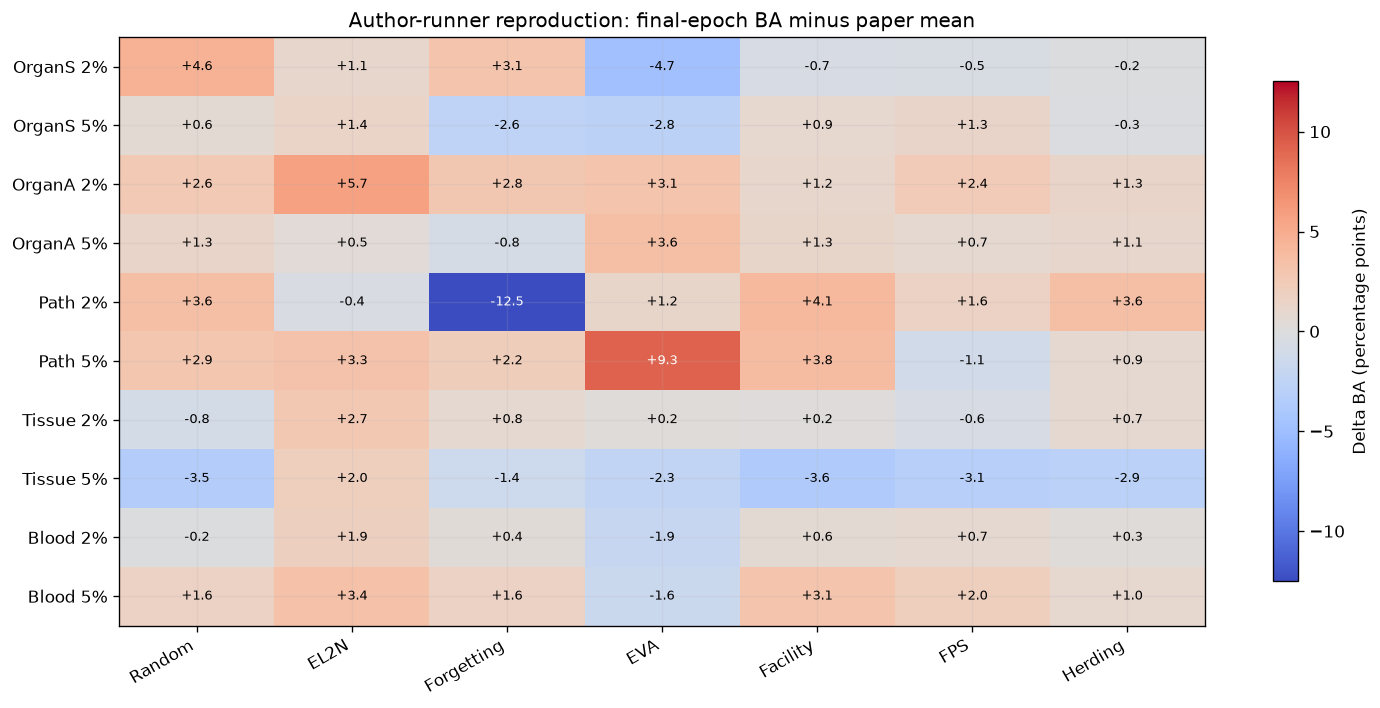

In [14]:
heat = results.copy()
heat['condition'] = pd.Categorical(
    heat.condition,
    [f"{DATASET_LABEL[d]} {r:.0%}" for d in DATASET_ORDER for r in [0.02, 0.05]],
    ordered=True,
)
heat['method_label'] = pd.Categorical(heat.method_label, [METHOD_LABEL[m] for m in MAIN_METHOD_ORDER], ordered=True)
heat = heat.pivot(index='condition', columns='method_label', values='delta_final_pp').sort_index()

fig, ax = plt.subplots(figsize=(12.5, 6.0))
limit = max(4.0, float(np.nanmax(np.abs(heat.to_numpy()))))
im = ax.imshow(heat.to_numpy(), cmap='coolwarm', vmin=-limit, vmax=limit, aspect='auto')
ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=30, ha='right')
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_title('Author-runner reproduction: final-epoch BA minus paper mean')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        ax.text(j, i, f'{value:+.1f}', ha='center', va='center', fontsize=8,
                color='white' if abs(value) > 0.55 * limit else 'black')
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Delta BA (percentage points)')
fig.tight_layout()
fig.savefig(FIGURES / 'seven_method_delta_heatmap.png', bbox_inches='tight')
plt.show()

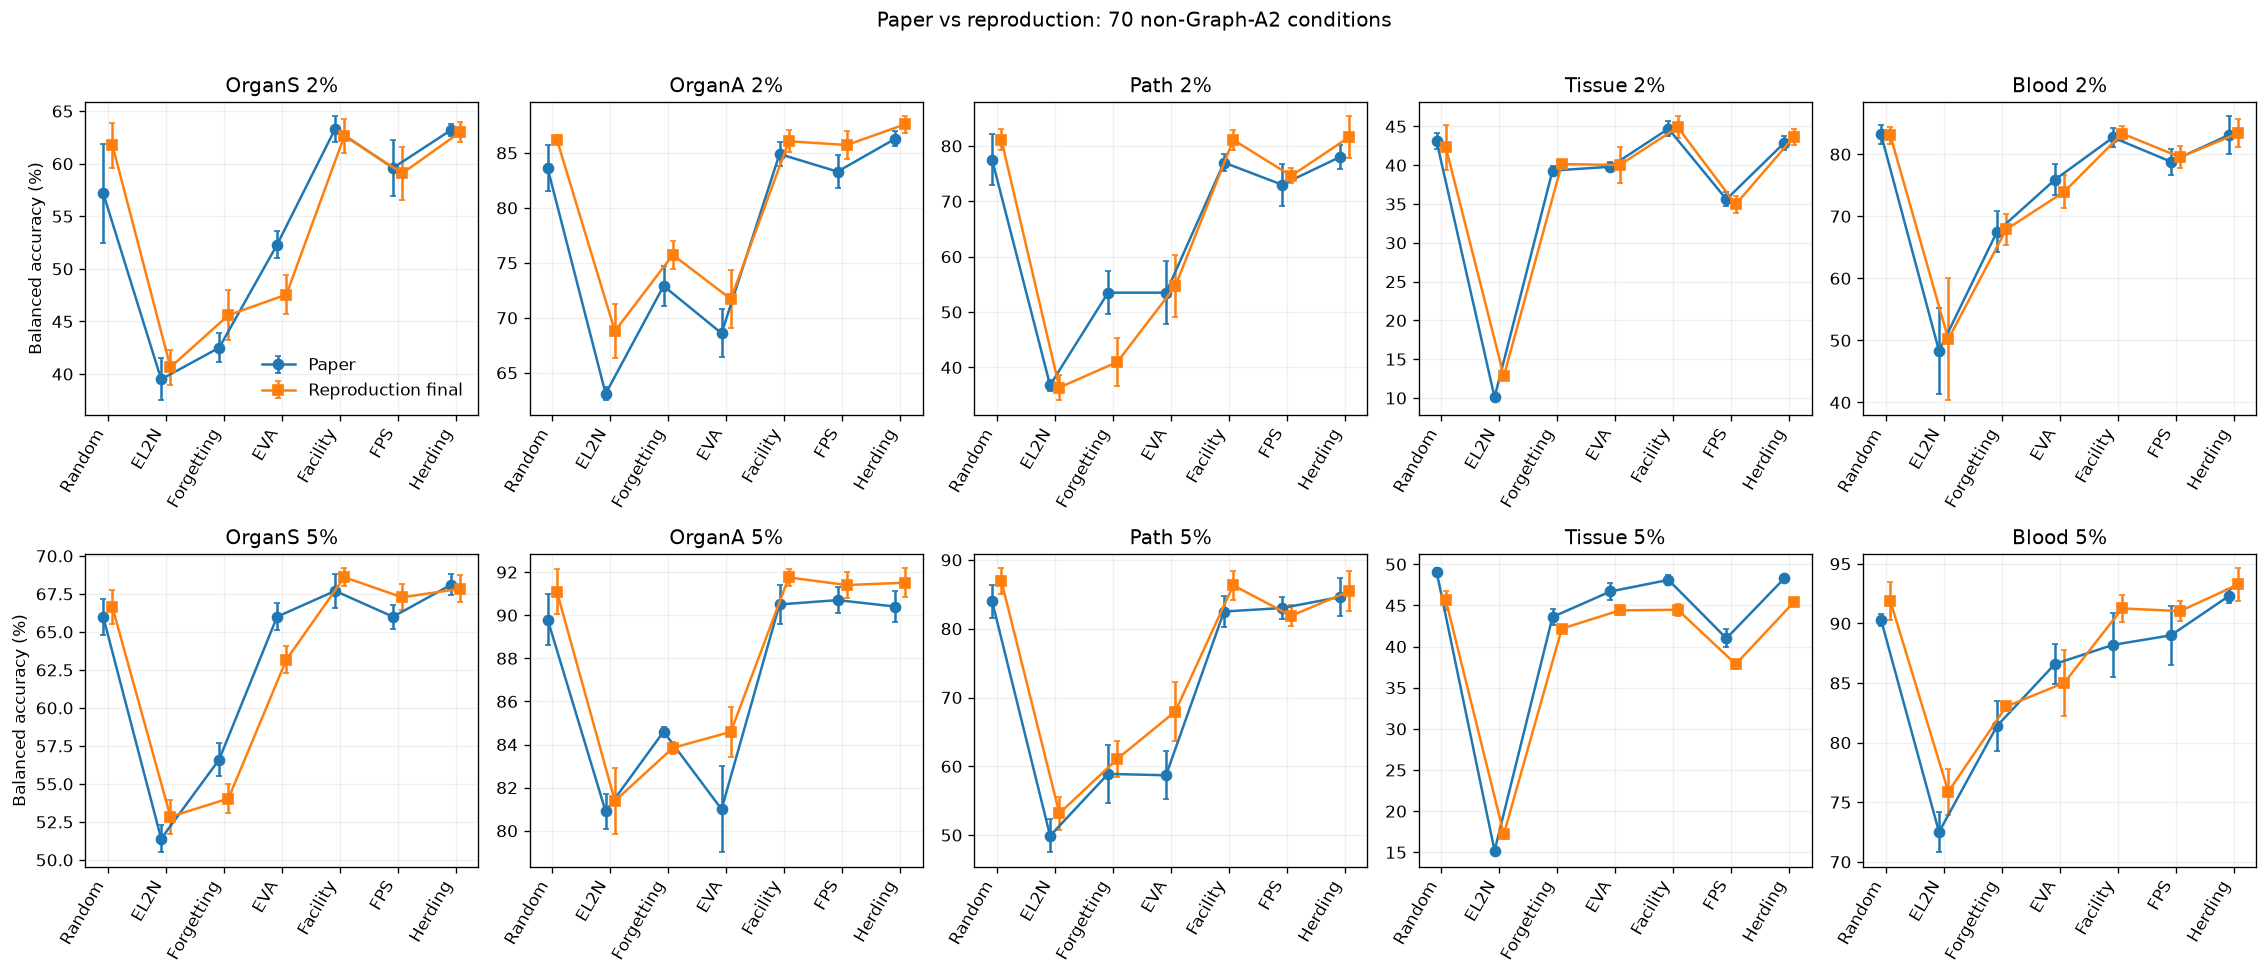

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(19, 8), sharey=False)
x = np.arange(len(MAIN_METHOD_ORDER))
for col, dataset in enumerate(DATASET_ORDER):
    for row, ratio in enumerate([0.02, 0.05]):
        ax = axes[row, col]
        sub = results[(results.dataset == dataset) & (results.ratio == ratio)].set_index('method').loc[MAIN_METHOD_ORDER]
        ax.errorbar(x - 0.08, sub.paper_mean_pct, yerr=sub.paper_std_pct, fmt='o-', capsize=2, label='Paper')
        ax.errorbar(x + 0.08, sub.final_balanced_accuracy_mean_pct,
                    yerr=sub.final_balanced_accuracy_std_pct, fmt='s-', capsize=2, label='Reproduction final')
        ax.set_title(f"{DATASET_LABEL[dataset]} {ratio:.0%}")
        ax.set_xticks(x, [METHOD_LABEL[m] for m in MAIN_METHOD_ORDER], rotation=60, ha='right')
        ax.set_ylabel('Balanced accuracy (%)' if col == 0 else '')
        if row == 0 and col == 0:
            ax.legend(frameon=False)
fig.suptitle('Paper vs reproduction: 70 non-Graph-A2 conditions', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'paper_vs_reproduction_seven_methods.png', bbox_inches='tight')
plt.show()

## 7. 按数据集、按方法汇总

In [16]:
dataset_summary = results.groupby('dataset_label', observed=True).agg(
    conditions=('method', 'size'),
    completed_runs=('n_seeds', 'sum'),
    mae_pp=('abs_delta_final_pp', 'mean'),
    mean_bias_pp=('delta_final_pp', 'mean'),
    max_abs_error_pp=('abs_delta_final_pp', 'max'),
    within_4pp=('within_4pp', 'sum'),
).reindex([DATASET_LABEL[d] for d in DATASET_ORDER])
dataset_summary['pass_rate_pct'] = dataset_summary.within_4pp / dataset_summary.conditions * 100
display(dataset_summary.round(2))

method_summary = results.groupby('method_label', observed=True).agg(
    conditions=('dataset', 'size'),
    completed_runs=('n_seeds', 'sum'),
    mae_pp=('abs_delta_final_pp', 'mean'),
    mean_bias_pp=('delta_final_pp', 'mean'),
    max_abs_error_pp=('abs_delta_final_pp', 'max'),
    within_4pp=('within_4pp', 'sum'),
).reindex([METHOD_LABEL[m] for m in MAIN_METHOD_ORDER])
method_summary['pass_rate_pct'] = method_summary.within_4pp / method_summary.conditions * 100
display(method_summary.round(2))

dataset_summary.to_csv(CALCULATED / 'summary_by_dataset.csv')
method_summary.to_csv(CALCULATED / 'summary_by_method.csv')

,conditions,completed_runs,mae_pp,mean_bias_pp,max_abs_error_pp,within_4pp,pass_rate_pct
dataset_label,,,,,,,
OrganS,14,70,1.77,0.09,4.75,12,85.71
OrganA,14,70,2.02,1.91,5.70,13,92.86
Path,14,70,3.60,1.59,12.52,11,78.57
Tissue,14,70,1.79,-0.83,3.63,14,100.00
Blood,14,70,1.45,0.92,3.39,14,100.00


,conditions,completed_runs,mae_pp,mean_bias_pp,max_abs_error_pp,within_4pp,pass_rate_pct
method_label,,,,,,,
Random,10,50,2.16,1.27,4.55,9,90.0
EL2N,10,50,2.25,2.16,5.70,9,90.0
Forgetting,10,50,2.82,-0.63,12.52,9,90.0
EVA,10,50,3.08,0.40,9.27,8,80.0
Facility,10,50,1.94,1.08,4.09,9,90.0
FPS,10,50,1.42,0.33,3.14,10,100.0
Herding,10,50,1.22,0.54,3.60,10,100.0


### 可直接放在组会第一页的结果摘要

In [17]:
best_method = method_summary.mae_pp.idxmin()
best_dataset = dataset_summary.mae_pp.idxmin()
failed = results.loc[~results.within_4pp]
display(Markdown(
    f'''
- 主口径：作者 runner 的 **final-epoch balanced accuracy**。
- 完整性：七种可比较方法 **70/70** 个条件有结果，完成 **{int(results.n_seeds.sum())}/350** 次训练。
- 复现度：**{int(results.within_4pp.sum())}/70 ({results.within_4pp.mean()*100:.1f}%)** 在 +/-4pp 内；整体 MAE **{results.abs_delta_final_pp.mean():.2f}pp**。
- 最接近论文的方法：**{best_method}**，10 格 MAE **{method_summary.loc[best_method, 'mae_pp']:.2f}pp**。
- 最接近论文的数据集：**{best_dataset}**，14 格 MAE **{dataset_summary.loc[best_dataset, 'mae_pp']:.2f}pp**。
- 超过 +/-4pp：**{len(failed)}** 格；必须逐格展示，不能只汇报总体通过率。
- best-test 仅为敏感性诊断：平均比 final 高 **{results.best_minus_final_pp.mean():.2f}pp**，最大高 **{results.best_minus_final_pp.max():.2f}pp**。
'''
))


- 主口径：作者 runner 的 **final-epoch balanced accuracy**。
- 完整性：七种可比较方法 **70/70** 个条件有结果，完成 **350/350** 次训练。
- 复现度：**64/70 (91.4%)** 在 +/-4pp 内；整体 MAE **2.13pp**。
- 最接近论文的方法：**Herding**，10 格 MAE **1.22pp**。
- 最接近论文的数据集：**Blood**，14 格 MAE **1.45pp**。
- 超过 +/-4pp：**6** 格；必须逐格展示，不能只汇报总体通过率。
- best-test 仅为敏感性诊断：平均比 final 高 **1.40pp**，最大高 **7.85pp**。


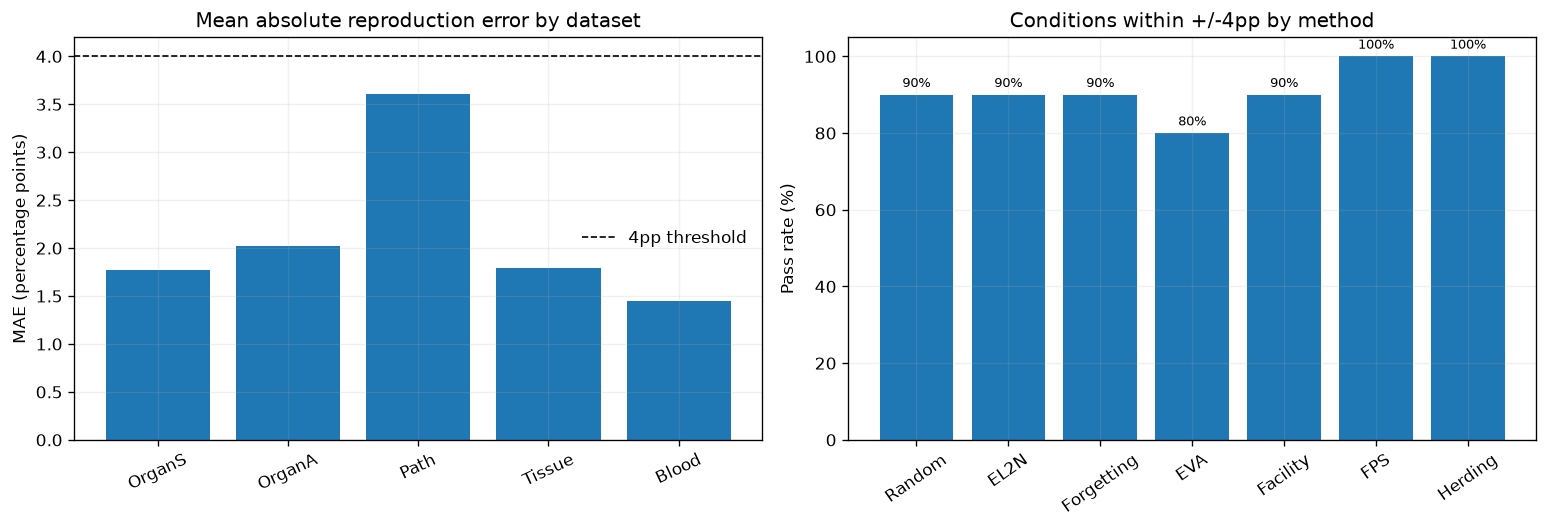

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(dataset_summary.index, dataset_summary.mae_pp)
axes[0].axhline(4, color='black', linestyle='--', linewidth=1, label='4pp threshold')
axes[0].set_title('Mean absolute reproduction error by dataset')
axes[0].set_ylabel('MAE (percentage points)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(frameon=False)

axes[1].bar(method_summary.index, method_summary.pass_rate_pct)
axes[1].set_ylim(0, 105)
axes[1].set_title('Conditions within +/-4pp by method')
axes[1].set_ylabel('Pass rate (%)')
axes[1].tick_params(axis='x', rotation=35)
for i, v in enumerate(method_summary.pass_rate_pct):
    axes[1].text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'reproduction_summary_by_dataset_method.png', bbox_inches='tight')
plt.show()

## 8. 为什么必须同时看 best 与 final

作者 runner 同时保存 final 与 best。主 `balanced_accuracy` 字段是 final；只有在汇总时主动选择 `best_balanced_accuracy`，才会发生用 test 挑 epoch 的泄漏。下面画出 `best test BA - final epoch BA`，用于显示如果误用 best 会把结果抬高多少，而不是把 best 当成主复现结果。

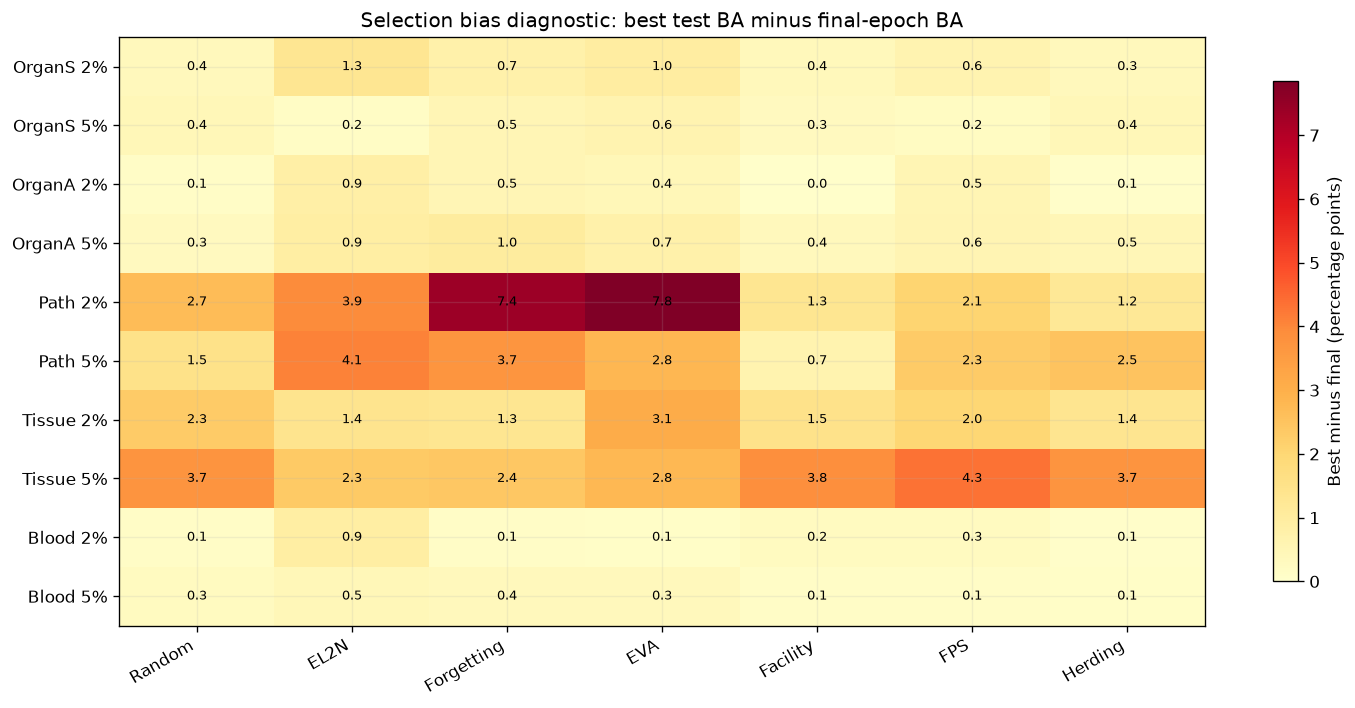

Mean best-test uplift: 1.40 pp
Maximum uplift: 7.85 pp


,dataset_label,ratio_label,method_label,best_balanced_accuracy_mean_pct,final_balanced_accuracy_mean_pct,best_minus_final_pp
35,Path,2%,EVA,62.53,54.68,7.85
34,Path,2%,Forgetting,48.36,40.98,7.38
61,Tissue,5%,FPS,42.18,37.86,4.32
41,Path,5%,EL2N,57.24,53.16,4.08
33,Path,2%,EL2N,40.30,36.36,3.93
60,Tissue,5%,Facility,48.31,44.47,3.84
56,Tissue,5%,Random,49.35,45.62,3.74
62,Tissue,5%,Herding,49.11,45.38,3.73
42,Path,5%,Forgetting,64.78,61.09,3.69
51,Tissue,2%,EVA,43.10,40.03,3.07


In [19]:
gap = results.pivot(index='condition', columns='method_label', values='best_minus_final_pp')
gap = gap.reindex(index=[f"{DATASET_LABEL[d]} {r:.0%}" for d in DATASET_ORDER for r in [0.02, 0.05]],
                  columns=[METHOD_LABEL[m] for m in MAIN_METHOD_ORDER])
fig, ax = plt.subplots(figsize=(12.5, 6.0))
im = ax.imshow(gap.to_numpy(), cmap='YlOrRd', vmin=0, vmax=float(np.nanmax(gap.to_numpy())), aspect='auto')
ax.set_xticks(range(len(gap.columns)), gap.columns, rotation=30, ha='right')
ax.set_yticks(range(len(gap.index)), gap.index)
ax.set_title('Selection bias diagnostic: best test BA minus final-epoch BA')
for i in range(gap.shape[0]):
    for j in range(gap.shape[1]):
        ax.text(j, i, f'{gap.iloc[i,j]:.1f}', ha='center', va='center', fontsize=8)
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Best minus final (percentage points)')
fig.tight_layout()
fig.savefig(FIGURES / 'best_test_minus_final_heatmap.png', bbox_inches='tight')
plt.show()

print(f"Mean best-test uplift: {results.best_minus_final_pp.mean():.2f} pp")
print(f"Maximum uplift: {results.best_minus_final_pp.max():.2f} pp")
display(results.nlargest(10, 'best_minus_final_pp')[[
    'dataset_label', 'ratio_label', 'method_label',
    'best_balanced_accuracy_mean_pct', 'final_balanced_accuracy_mean_pct', 'best_minus_final_pp'
]].round(2))

## 9. k=50 严格 Path/Blood pilot（test 只评一次）

这 32 条结果来自另一个隔离包：Graph-A2 修正为论文证据支持的 `k=50,H=2`，训练时用 validation 选择 checkpoint，test 在最后只访问一次。它比上面的公开协议更适合判断测试效果，但目前只有 Path/Blood、seed42，所以误差中仍包含较大的单 seed 随机性。

In [20]:
with (EVIDENCE / 'strict_k50_path_blood_seed42.json').open(encoding='utf-8-sig') as f:
    strict = pd.DataFrame(json.load(f))
assert len(strict) == 32
assert strict.test_evaluations.eq(1).all()
assert strict.training_seed.eq(42).all()

strict['test_ba_pct'] = strict.balanced_accuracy * 100
strict['test_acc_pct'] = strict.accuracy * 100
strict['best_val_ba_pct'] = strict.best_val_balanced_accuracy * 100
strict['selected_indices_path_hpc'] = strict.selection_path.map(
    lambda value: (
        f"{REMOTE_STRICT}/outputs/job1_selection_k50_global/" +
        str(value).replace('\\\\', '/').split('/outputs/job1_selection_k50_global/', 1)[1]
    )
)
strict = strict.merge(paper, on=['dataset', 'ratio', 'method'], validate='many_to_one')
strict['delta_pp'] = strict.test_ba_pct - strict.paper_mean_pct
strict['within_4pp'] = strict.delta_pp.abs() <= 4
strict['dataset_label'] = strict.dataset.map(DATASET_LABEL)
strict['method_label'] = strict.method.map(METHOD_LABEL)
strict['ratio_label'] = strict.ratio.map(lambda x: f'{x:.0%}')

strict_table = strict[[
    'dataset_label', 'ratio_label', 'method_label', 'training_seed',
    'test_acc_pct', 'test_ba_pct',
    'paper_mean_pct', 'paper_std_pct', 'delta_pp', 'within_4pp',
    'best_val_ba_pct', 'best_epoch', 'selection_index_sha256',
    'selected_indices_path_hpc'
]].sort_values(['dataset_label', 'ratio_label', 'method_label'])
display(strict_table.round(2))
print(f"Strict pilot within +/-4pp: {strict.within_4pp.sum()}/32 ({strict.within_4pp.mean()*100:.1f}%)")

strict_graph_a2 = strict[strict.method == 'graph_a2'][[
    'dataset', 'ratio', 'training_seed', 'test_acc_pct', 'test_ba_pct',
    'paper_mean_pct', 'paper_std_pct', 'delta_pp', 'within_4pp',
    'best_val_ba_pct', 'best_epoch', 'selection_index_sha256',
    'selected_indices_path_hpc'
]].sort_values(['dataset', 'ratio'])
display(Markdown('### B 层中 Graph-A2 `global, k=50, H=2` 的四格结果'))
display(strict_graph_a2.round(3))
strict_table.to_csv(CALCULATED / 'strict_k50_path_blood_all_methods_seed42.csv', index=False)
strict_graph_a2.to_csv(CALCULATED / 'strict_k50_graph_a2_seed42.csv', index=False)
strict[[
    'dataset', 'ratio', 'method', 'training_seed', 'test_acc_pct', 'test_ba_pct',
    'selection_index_sha256', 'selected_indices_path_hpc'
]].sort_values(['dataset', 'ratio', 'method']).to_csv(
    CALCULATED / 'downstream_acc_ba_layer_b_strict_seed42.csv', index=False
)

,dataset_label,ratio_label,method_label,training_seed,test_acc_pct,test_ba_pct,paper_mean_pct,paper_std_pct,delta_pp,within_4pp,best_val_ba_pct,best_epoch,selection_index_sha256,selected_indices_path_hpc
0,Blood,2%,EL2N,42,54.31,51.65,48.3,6.9,3.35,True,51.20,410,334bc30ef7b2585c702b795f840e31df11b5e6439e1615...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
1,Blood,2%,EVA,42,79.01,75.99,75.9,2.5,0.09,True,77.62,960,1434a8e30c6d1a805595f2dc923ca83dbf062f48f95ace...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
4,Blood,2%,FPS,42,78.63,78.74,78.8,2.1,-0.06,True,78.95,930,3ca08ab70027e9066d00d7a318f2d083901503b5513e03...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
2,Blood,2%,Facility,42,82.29,82.14,82.7,1.6,-0.56,True,83.53,680,b07ef001913453eaf1eacfee96c9e8de36f610f2313ca5...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
3,Blood,2%,Forgetting,42,69.72,67.10,67.5,3.3,-0.40,True,67.99,880,a1ebfd631688caac4c9951d671e78e26246fcb65f3c33b...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
5,Blood,2%,Graph-A2,42,81.26,81.02,84.5,1.7,-3.48,True,83.07,860,5172a4d967e291669590b73ce004c76a91f1b8058a4264...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
6,Blood,2%,Herding,42,85.59,86.05,83.1,3.0,2.95,True,87.86,890,ac4526125c976c6e2f52626887f9e0b1999a82f9e18c55...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
7,Blood,2%,Random,42,80.15,79.91,83.2,1.5,-3.29,True,81.30,830,ec622b4f1b2495851bf7fbc635b294b605346ff97cbc9d...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
8,Blood,5%,EL2N,42,74.69,75.17,72.5,1.7,2.67,True,76.15,550,fd6e7d3f41c4ee704d3f8f97e4eef8379e715508eb5cad...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
9,Blood,5%,EVA,42,88.07,86.31,86.6,1.7,-0.29,True,87.59,960,b331684a746edeb1cf53ab4688d691753cce6ac3f0cdf5...,/project/PROJECT_ROOT/USER/_archive_fork_2026...


Strict pilot within +/-4pp: 22/32 (68.8%)


### B 层中 Graph-A2 `global, k=50, H=2` 的四格结果

,dataset,ratio,training_seed,test_acc_pct,test_ba_pct,paper_mean_pct,paper_std_pct,delta_pp,within_4pp,best_val_ba_pct,best_epoch,selection_index_sha256,selected_indices_path_hpc
5,bloodmnist,0.02,42,81.263,81.018,84.5,1.7,-3.482,True,83.073,860,5172a4d967e291669590b73ce004c76a91f1b8058a4264...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
13,bloodmnist,0.05,42,91.172,91.571,93.4,0.7,-1.829,True,92.992,980,d06be5ac2f4361ec295fa69b11d06085e4f2cc3a723fd8...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
21,pathmnist,0.02,42,87.730,85.110,80.9,0.9,4.210,False,95.085,570,643ebf4a0682d3ec08eb6ba2e7be07bd1f70ed2753265f...,/project/PROJECT_ROOT/USER/_archive_fork_2026...
29,pathmnist,0.05,42,89.540,87.328,85.9,1.7,1.428,True,96.057,150,b60ace052d251228dd887ea8fe31f20c7f202cafa14f29...,/project/PROJECT_ROOT/USER/_archive_fork_2026...


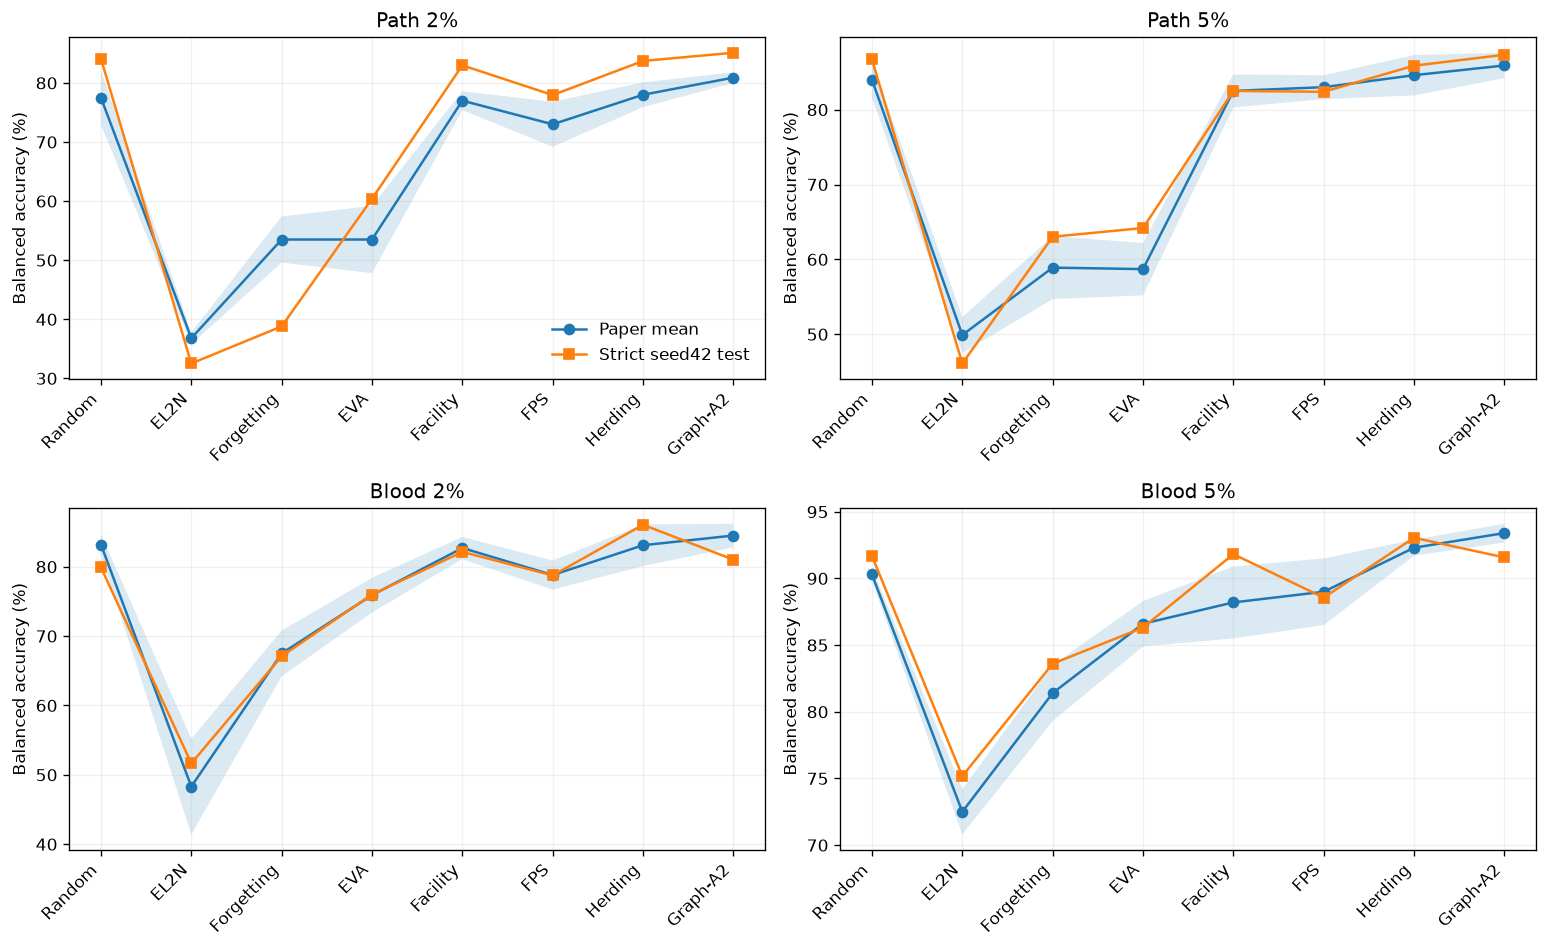

In [21]:
strict_plot = strict.copy()
strict_plot['condition'] = strict_plot.dataset_label + ' ' + strict_plot.ratio_label
conditions = ['Path 2%', 'Path 5%', 'Blood 2%', 'Blood 5%']
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)
x = np.arange(len(METHOD_ORDER))
for ax, cond in zip(axes.ravel(), conditions):
    sub = strict_plot[strict_plot.condition == cond].set_index('method').loc[METHOD_ORDER]
    ax.plot(x, sub.paper_mean_pct, 'o-', label='Paper mean')
    ax.plot(x, sub.test_ba_pct, 's-', label='Strict seed42 test')
    ax.fill_between(x, sub.paper_mean_pct-sub.paper_std_pct,
                    sub.paper_mean_pct+sub.paper_std_pct, alpha=0.16)
    ax.set_title(cond)
    ax.set_xticks(x, [METHOD_LABEL[m] for m in METHOD_ORDER], rotation=45, ha='right')
    ax.set_ylabel('Balanced accuracy (%)')
axes[0,0].legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / 'strict_k50_path_blood_seed42.png', bbox_inches='tight')
plt.show()

## 10. Path 上 k=50 Graph-A2 的五种子独立确认

这组结果不覆盖主表，而是回答一个更窄的问题：当 Graph-A2 使用论文证据支持的 `k=50,H=2`，固定同一份选择 indices，只改变下游训练 seed 42--46 时，Path 的结果是否仍接近论文。

这里报告 CSV 的 **final-epoch BA**；Slurm 命令没有启用 deterministic，因此它是五次随机训练的经验分布，不是 canonical 方法开发协议。

,ratio,n_seeds,seeds,final_acc_mean,final_acc_std,final_acc_min,final_acc_max,final_ba_mean,final_ba_std,final_ba_min,final_ba_max,selected_sha256,paper_mean_pct,paper_std_pct,delta_pp,within_4pp
0,0.02,5,"42,43,44,45,46",85.758,1.884,83.635,88.691,82.218,3.147,77.465,85.541,81100af020f308e01e3325ef0e551659b9f14a32cede7d...,80.9,0.9,1.318,True
1,0.05,5,"42,43,44,45,46",89.866,0.357,89.345,90.223,87.236,0.466,86.644,87.844,c896a7fa5b0d22cf3d74802b8ac802a02db4cfce7c09e1...,85.9,1.7,1.336,True


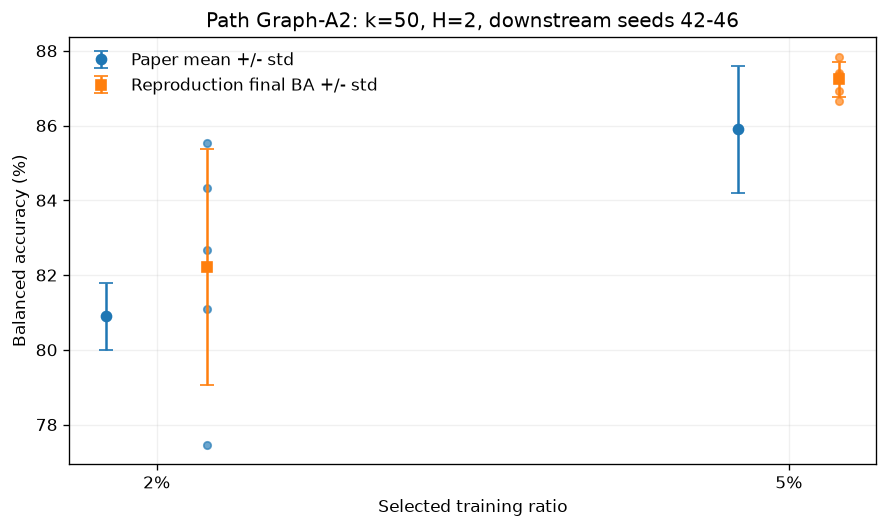

In [22]:
k50_path_results = PROJECT_ROOT / 'graph-a2-path-seed42-validation' / 'reports' / 'weekly_results_snapshot' / 'path_graph_a2_multiseed.csv'
k50_path = pd.read_csv(k50_path_results)
assert len(k50_path) == 10
assert set(k50_path.seed) == {42, 43, 44, 45, 46}
assert k50_path.groupby('ratio').selected_sha256.nunique().eq(1).all()

k50_path['final_ba_pct'] = k50_path.balanced_accuracy * 100
k50_path['final_acc_pct'] = k50_path.accuracy * 100
k50_summary = k50_path.groupby('ratio').agg(
    n_seeds=('seed', 'nunique'),
    seeds=('seed', lambda s: ','.join(map(str, sorted(s)))),
    final_acc_mean=('final_acc_pct', 'mean'),
    final_acc_std=('final_acc_pct', 'std'),
    final_acc_min=('final_acc_pct', 'min'),
    final_acc_max=('final_acc_pct', 'max'),
    final_ba_mean=('final_ba_pct', 'mean'),
    final_ba_std=('final_ba_pct', 'std'),
    final_ba_min=('final_ba_pct', 'min'),
    final_ba_max=('final_ba_pct', 'max'),
    selected_sha256=('selected_sha256', 'first'),
).reset_index()
k50_paper = paper[(paper.dataset == 'pathmnist') & (paper.method == 'graph_a2')][
    ['ratio', 'paper_mean_pct', 'paper_std_pct']
]
k50_summary = k50_summary.merge(k50_paper, on='ratio', validate='one_to_one')
k50_summary['delta_pp'] = k50_summary.final_ba_mean - k50_summary.paper_mean_pct
k50_summary['within_4pp'] = k50_summary.delta_pp.abs() <= 4
display(k50_summary.round(3))
k50_path[[
    'dataset', 'ratio', 'seed', 'final_acc_pct', 'final_ba_pct',
    'selected_sha256', 'selection_path'
]].sort_values(['ratio', 'seed']).to_csv(
    CALCULATED / 'downstream_acc_ba_layer_c_path_graph_a2_by_seed.csv', index=False
)
k50_summary.to_csv(
    CALCULATED / 'downstream_acc_ba_layer_c_path_graph_a2_summary.csv', index=False
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
positions = np.arange(len(k50_summary))
ax.errorbar(positions - 0.08, k50_summary.paper_mean_pct, yerr=k50_summary.paper_std_pct,
            fmt='o', capsize=4, label='Paper mean +/- std')
ax.errorbar(positions + 0.08, k50_summary.final_ba_mean, yerr=k50_summary.final_ba_std,
            fmt='s', capsize=4, label='Reproduction final BA +/- std')
for x_pos, ratio in enumerate(k50_summary.ratio):
    values = k50_path.loc[k50_path.ratio == ratio, 'final_ba_pct']
    ax.scatter(np.full(len(values), x_pos + 0.08), values, s=20, alpha=0.65)
ax.set_xticks(positions, [f'{ratio:.0%}' for ratio in k50_summary.ratio])
ax.set_ylabel('Balanced accuracy (%)')
ax.set_xlabel('Selected training ratio')
ax.set_title('Path Graph-A2: k=50, H=2, downstream seeds 42-46')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / 'path_k50_graph_a2_multiseed.png', bbox_inches='tight')
plt.show()

### Graph-A2 `k=50,H=2`：十个 Table 1 条件目前完成了哪些

下表采用“每个条件当前最完整且参数正确的证据”：Path 使用五种子 final-epoch；Blood 目前只有严格 seed42 validation-checkpoint；OrganS、OrganA、Tissue 明确留空。Blood 与 Path 的训练协议不同，因此本表只展示证据完整性和逐格差值，**不计算跨数据集平均值或方法排名**。

In [23]:
graph_paper = paper[paper.method == 'graph_a2'][
    ['dataset', 'ratio', 'paper_mean_pct', 'paper_std_pct']
].copy()
graph_rows = []
for row in graph_paper.itertuples(index=False):
    item = {
        'dataset': row.dataset,
        'ratio': row.ratio,
        'paper_mean_pct': row.paper_mean_pct,
        'paper_std_pct': row.paper_std_pct,
        'reproduction_acc_mean_pct': np.nan,
        'reproduction_acc_std_pct': np.nan,
        'reproduction_mean_pct': np.nan,
        'reproduction_std_pct': np.nan,
        'n_seeds': 0,
        'protocol': 'not completed',
    }
    if row.dataset == 'pathmnist':
        match = k50_summary[k50_summary.ratio == row.ratio].iloc[0]
        item.update({
            'reproduction_acc_mean_pct': match.final_acc_mean,
            'reproduction_acc_std_pct': match.final_acc_std,
            'reproduction_mean_pct': match.final_ba_mean,
            'reproduction_std_pct': match.final_ba_std,
            'n_seeds': int(match.n_seeds),
            'protocol': 'final epoch; fixed indices; downstream seeds 42-46',
        })
    elif row.dataset == 'bloodmnist':
        match = strict_graph_a2[
            (strict_graph_a2.dataset == row.dataset) & (strict_graph_a2.ratio == row.ratio)
        ].iloc[0]
        item.update({
            'reproduction_acc_mean_pct': match.test_acc_pct,
            'reproduction_acc_std_pct': np.nan,
            'reproduction_mean_pct': match.test_ba_pct,
            'reproduction_std_pct': np.nan,
            'n_seeds': 1,
            'protocol': 'validation checkpoint; seed42; test evaluated once',
        })
    graph_rows.append(item)

graph_a2_k50_evidence = pd.DataFrame(graph_rows)
graph_a2_k50_evidence['delta_pp'] = (
    graph_a2_k50_evidence.reproduction_mean_pct - graph_a2_k50_evidence.paper_mean_pct
)
graph_a2_k50_evidence['within_4pp'] = np.where(
    graph_a2_k50_evidence.reproduction_mean_pct.notna(),
    graph_a2_k50_evidence.delta_pp.abs() <= 4,
    pd.NA,
)
graph_a2_k50_evidence['dataset_label'] = graph_a2_k50_evidence.dataset.map(DATASET_LABEL)
graph_a2_k50_evidence['ratio_label'] = graph_a2_k50_evidence.ratio.map(lambda value: f'{value:.0%}')
graph_a2_k50_evidence = graph_a2_k50_evidence.sort_values(
    ['dataset_label', 'ratio'],
    key=lambda values: values.map({label: i for i, label in enumerate(DATASET_LABEL.values())})
    if values.name == 'dataset_label' else values,
)
display(graph_a2_k50_evidence[[
    'dataset_label', 'ratio_label', 'paper_mean_pct', 'paper_std_pct',
    'reproduction_acc_mean_pct', 'reproduction_acc_std_pct',
    'reproduction_mean_pct', 'reproduction_std_pct', 'n_seeds',
    'delta_pp', 'within_4pp', 'protocol'
]].round(3))
graph_a2_k50_evidence.to_csv(CALCULATED / 'graph_a2_k50_available_evidence.csv', index=False)

graph_cells = {}
for row in graph_a2_k50_evidence.itertuples(index=False):
    condition = f'{row.dataset_label} {row.ratio_label}'
    if pd.isna(row.reproduction_mean_pct):
        graph_cells[condition] = 'not completed'
    else:
        spread = f'+/-{row.reproduction_std_pct:.1f}' if pd.notna(row.reproduction_std_pct) else 'single seed'
        graph_cells[condition] = (
            f'{row.reproduction_mean_pct:.1f} {spread} | '
            f'paper {row.paper_mean_pct:.1f}+/-{row.paper_std_pct:.1f} | '
            f'D {row.delta_pp:+.1f}'
        )

table1_style_available = main_table.copy()
table1_style_available['Graph-A2 k=50 (available evidence)'] = [
    graph_cells[str(condition)] for condition in table1_style_available.index
]
display(Markdown('### 当前可审计的 Table 1 风格总览'))
display(table1_style_available)
table1_style_available.to_csv(CALCULATED / 'table1_style_available_evidence.csv')

,dataset_label,ratio_label,paper_mean_pct,paper_std_pct,reproduction_acc_mean_pct,reproduction_acc_std_pct,reproduction_mean_pct,reproduction_std_pct,n_seeds,delta_pp,within_4pp,protocol
0,OrganS,2%,63.7,0.7,NaN,NaN,NaN,NaN,0,NaN,<NA>,not completed
1,OrganS,5%,68.4,1.0,NaN,NaN,NaN,NaN,0,NaN,<NA>,not completed
2,OrganA,2%,86.5,0.9,NaN,NaN,NaN,NaN,0,NaN,<NA>,not completed
3,OrganA,5%,91.9,0.3,NaN,NaN,NaN,NaN,0,NaN,<NA>,not completed
4,Path,2%,80.9,0.9,85.758,1.884,82.218,3.147,5,1.318,True,final epoch; fixed indices; downstream seeds 4...
5,Path,5%,85.9,1.7,89.866,0.357,87.236,0.466,5,1.336,True,final epoch; fixed indices; downstream seeds 4...
6,Tissue,2%,42.6,0.6,NaN,NaN,NaN,NaN,0,NaN,<NA>,not completed
7,Tissue,5%,49.5,1.3,NaN,NaN,NaN,NaN,0,NaN,<NA>,not completed
8,Blood,2%,84.5,1.7,81.263,NaN,81.018,NaN,1,-3.482,True,validation checkpoint; seed42; test evaluated ...
9,Blood,5%,93.4,0.7,91.172,NaN,91.571,NaN,1,-1.829,True,validation checkpoint; seed42; test evaluated ...


### 当前可审计的 Table 1 风格总览

method_label,Random,EL2N,Forgetting,EVA,Facility,FPS,Herding,Graph-A2 k=50 (available evidence)
condition,,,,,,,,
OrganS 2%,61.8+/-2.1 | paper 57.2+/-4.7 | D +4.6,40.6+/-1.7 | paper 39.5+/-2.0 | D +1.1,45.6+/-2.4 | paper 42.5+/-1.4 | D +3.1,47.6+/-1.9 | paper 52.3+/-1.3 | D -4.7,62.6+/-1.6 | paper 63.3+/-1.2 | D -0.7,59.1+/-2.5 | paper 59.6+/-2.7 | D -0.5,63.0+/-1.0 | paper 63.2+/-0.6 | D -0.2,not completed
OrganS 5%,66.6+/-1.1 | paper 66.0+/-1.2 | D +0.6,52.8+/-1.1 | paper 51.4+/-0.9 | D +1.4,54.0+/-1.0 | paper 56.6+/-1.1 | D -2.6,63.2+/-0.9 | paper 66.0+/-0.9 | D -2.8,68.6+/-0.6 | paper 67.7+/-1.1 | D +0.9,67.3+/-0.9 | paper 66.0+/-0.8 | D +1.3,67.8+/-0.9 | paper 68.1+/-0.7 | D -0.3,not completed
OrganA 2%,86.2+/-0.4 | paper 83.6+/-2.1 | D +2.6,68.8+/-2.4 | paper 63.1+/-0.6 | D +5.7,75.7+/-1.3 | paper 72.9+/-1.8 | D +2.8,71.7+/-2.7 | paper 68.6+/-2.2 | D +3.1,86.1+/-1.0 | paper 84.9+/-1.1 | D +1.2,85.7+/-1.3 | paper 83.3+/-1.5 | D +2.4,87.6+/-0.7 | paper 86.3+/-0.7 | D +1.3,not completed
OrganA 5%,91.1+/-1.0 | paper 89.8+/-1.2 | D +1.3,81.4+/-1.5 | paper 80.9+/-0.8 | D +0.5,83.8+/-0.3 | paper 84.6+/-0.2 | D -0.8,84.6+/-1.1 | paper 81.0+/-2.0 | D +3.6,91.8+/-0.4 | paper 90.5+/-0.9 | D +1.3,91.4+/-0.6 | paper 90.7+/-0.6 | D +0.7,91.5+/-0.7 | paper 90.4+/-0.7 | D +1.1,not completed
Path 2%,81.1+/-1.9 | paper 77.5+/-4.6 | D +3.6,36.4+/-2.3 | paper 36.8+/-1.0 | D -0.4,41.0+/-4.4 | paper 53.5+/-3.9 | D -12.5,54.7+/-5.6 | paper 53.5+/-5.7 | D +1.2,81.1+/-1.8 | paper 77.0+/-1.6 | D +4.1,74.6+/-1.4 | paper 73.0+/-3.8 | D +1.6,81.6+/-3.7 | paper 78.0+/-2.1 | D +3.6,82.2 +/-3.1 | paper 80.9+/-0.9 | D +1.3
Path 5%,86.9+/-1.9 | paper 84.0+/-2.4 | D +2.9,53.2+/-2.4 | paper 49.9+/-2.4 | D +3.3,61.1+/-2.6 | paper 58.9+/-4.2 | D +2.2,68.0+/-4.3 | paper 58.7+/-3.5 | D +9.3,86.3+/-2.1 | paper 82.5+/-2.2 | D +3.8,81.9+/-1.5 | paper 83.0+/-1.6 | D -1.1,85.5+/-2.9 | paper 84.6+/-2.7 | D +0.9,87.2 +/-0.5 | paper 85.9+/-1.7 | D +1.3
Tissue 2%,42.3+/-2.9 | paper 43.1+/-1.0 | D -0.8,12.8+/-0.5 | paper 10.1+/-0.4 | D +2.7,40.1+/-0.5 | paper 39.3+/-0.6 | D +0.8,40.0+/-2.3 | paper 39.8+/-0.6 | D +0.2,44.9+/-1.4 | paper 44.7+/-1.0 | D +0.2,35.0+/-1.1 | paper 35.6+/-0.9 | D -0.6,43.6+/-1.0 | paper 42.9+/-0.9 | D +0.7,not completed
Tissue 5%,45.6+/-1.2 | paper 49.1+/-0.4 | D -3.5,17.2+/-0.6 | paper 15.2+/-0.2 | D +2.0,42.2+/-0.5 | paper 43.6+/-1.0 | D -1.4,44.4+/-0.5 | paper 46.7+/-1.0 | D -2.3,44.5+/-0.8 | paper 48.1+/-0.6 | D -3.6,37.9+/-0.5 | paper 41.0+/-1.1 | D -3.1,45.4+/-0.5 | paper 48.3+/-0.4 | D -2.9,not completed
Blood 2%,83.0+/-1.4 | paper 83.2+/-1.5 | D -0.2,50.2+/-9.9 | paper 48.3+/-6.9 | D +1.9,67.9+/-2.5 | paper 67.5+/-3.3 | D +0.4,74.0+/-2.7 | paper 75.9+/-2.5 | D -1.9,83.3+/-1.2 | paper 82.7+/-1.6 | D +0.6,79.5+/-1.8 | paper 78.8+/-2.1 | D +0.7,83.4+/-2.2 | paper 83.1+/-3.0 | D +0.3,81.0 single seed | paper 84.5+/-1.7 | D -3.5


## 11. 结果应该怎样解释

**可以说的：**

- 排除图参数不匹配的 Graph-A2 后，七种基线覆盖 70/70 个条件，已完成 350/350 个真实下游训练结果；不是只挑了几个成功样例。
- 几何方法与 training-dynamics 方法的行为明显不同：前者通常更接近 Random/Herding 的强基线，后者在不同数据集和低预算下波动更大。
- Graph-A2 只报告 `global, k=50, H=2`：Path/Blood 的严格 seed42，以及 Path 的五种子 final-epoch 确认。
- Path 的 k=50 Graph-A2 五种子 final BA 是独立确认层；它支持“Path Graph-A2 接近论文”，但不能补齐 OrganS、OrganA、Tissue 的 6 个 Graph-A2 条件。
- ±4pp 是一个直观工程容差；Notebook 已按同一规则逐格计算通过率。

**不能说的：**

- 不能把 `best_balanced_accuracy` 当成作者的主 `balanced_accuracy` 字段；它只是 test-selected 诊断值。
- 也不能断言论文 Table 1 一定用了 final：现有代码证明 runner 主字段是 final，但缺少论文制表脚本来闭合最后一环。
- 七种方法的 70 个条件均已完成五个 training seeds，共 350/350 个 A 层结果。
- 不能把已排除的 Graph-A2 原始归档结果重新放回主表。
- 不能从 seed42 严格 pilot 推断统计显著性或 SOTA。

In [24]:
failed_4pp = results.loc[~results.within_4pp, [
    'dataset_label', 'ratio_label', 'method_label', 'n_seeds',
    'final_balanced_accuracy_mean_pct', 'paper_mean_pct', 'delta_final_pp', 'sigma_final'
]].sort_values('delta_final_pp')
display(Markdown('### 公开协议中超出 +/-4pp 的条件'))
display(failed_4pp.round(2))

missing_runs = results.loc[results.n_seeds < 5, [
    'dataset_label', 'ratio_label', 'method_label', 'n_seeds', 'training_seeds'
]].sort_values(['dataset_label', 'ratio_label', 'method_label'])
display(Markdown('### 尚未达到 5 seeds 的条件'))
display(missing_runs)
print('Missing downstream runs among seven comparable methods:', int(350 - results.n_seeds.sum()))

### 公开协议中超出 +/-4pp 的条件

,dataset_label,ratio_label,method_label,n_seeds,final_balanced_accuracy_mean_pct,paper_mean_pct,delta_final_pp,sigma_final
34,Path,2%,Forgetting,5,40.98,53.5,-12.52,3.21
3,OrganS,2%,EVA,5,47.55,52.3,-4.75,3.65
36,Path,2%,Facility,5,81.09,77.0,4.09,2.56
0,OrganS,2%,Random,5,61.75,57.2,4.55,0.97
17,OrganA,2%,EL2N,5,68.80,63.1,5.70,9.50
43,Path,5%,EVA,5,67.97,58.7,9.27,2.65


### 尚未达到 5 seeds 的条件

,dataset_label,ratio_label,method_label,n_seeds,training_seeds


Missing downstream runs among seven comparable methods: 0


## 12. 组会最后一页：结论与下一步

1. **复现资产已经找回**：七种基线的完整汇总、配置、作者代码哈希和 Graph-A2 严格 pilot 都已固化到本 Notebook 同目录的 `evidence/`。
2. **当前能汇报的是“分层复现”**：七种基线以 final 字段覆盖 70 个条件；Graph-A2 只保留 `k=50,H=2`，其中 validation-checkpoint 层覆盖 Path/Blood seed42，Path 另有五种子 final-epoch 确认。
3. **优先补实验而不是继续调新方法**：先补齐 k=50 严格协议的五数据集、八方法、两比例、五 seeds，再谈统一 Table 1。
4. **方法改进必须在 canonical 协议下做**：冻结 indices、相同训练 seed、final epoch BA、test 不参与方法筛选。当前的新方法开发结果不能倒灌进 Table 1 复现表。

汇报时建议用第 6、7、8 节三张图：先展示 final-epoch 全局误差，再展示按数据集/方法的稳定性，最后说明误用 best-test 会产生多大的乐观偏差。

## 13. 代码、配置、结果与日志路径

**本地代码**

- `table1_reproduction/vendor/graphcov/`：作者代码快照。
- `table1_reproduction/experiments/job1_select.py`：生成并冻结选择 indices。
- `table1_reproduction/experiments/job2_downstream.py`：读取冻结 indices，训练与测试。
- `table1_reproduction/vendor/graphcov/run/selection.py`：八种选择方法实现。
- `table1_reproduction/vendor/graphcov/run/eva.py`：EL2N/EVA/Forgetting 的代理轨迹。
- `table1_reproduction/vendor/graphcov/run/evaluation.py`：ResNet18 训练与 BA 计算。

**HPC 原始公开协议结果**

- `/project/PROJECT_ROOT/USER/_archive_fork_20260830/graph_bench/table1_reproduction/outputs/job2_table1/`
- `/project/PROJECT_ROOT/USER/_archive_fork_20260830/graph_bench/table1_reproduction/logs/job2_26839_*.out`
- `/project/PROJECT_ROOT/USER/_archive_fork_20260830/graph_bench/table1_reproduction/logs/job2_26839_*.err`

**HPC 原始 k=50 严格 pilot**

- `/project/PROJECT_ROOT/USER/_archive_fork_20260830/table1_strict_repro/table1_reproduction/outputs/job2_path_blood_single_seed_valckpt/`

**Path k=50 Graph-A2 五种子确认**

- 本地 CSV：`graph-a2-path-seed42-validation/reports/weekly_results_snapshot/path_graph_a2_multiseed.csv`
- 本地 Slurm：`graph-a2-path-seed42-validation/hpc/path_multiseed_graph_a2.slurm`
- HPC 原始结果：`/project/PROJECT_ROOT/USER/graph_a2_path_seed42_validation/results/path_multiseed_confirmatory/graph_a2_k50_h2/results.csv`
- HPC 日志规则：`/project/PROJECT_ROOT/USER/graph_a2_path_seed42_validation/logs/multiseed_graph_%j.out`

**本地离线证据**

- `reports/table1_group_meeting/evidence/public_k10_394run_per_condition_mean_std.csv`：394-run 原始汇总；Notebook 主表从其中的 final BA 列计算。
- `table1_reproduction/outputs/job2_table1/bloodmnist/`：本次补齐的 12 个 BloodMNIST `test_result.json`。
- `reports/table1_group_meeting/evidence/`：汇总 CSV/Markdown、配置 JSON、作者代码哈希、补跑日志和 sacct 证据。
- 本 Notebook 同目录的 `figures/`：运行后生成的 PNG 图。
- 本 Notebook 同目录的 `calculated_tables/`：Notebook 现场计算并导出的论文表、复现表、Delta 表与汇总表。

**本次补跑远端原始位置**

- `/project/PROJECT_ROOT/USER/_archive_fork_20260830/graph_bench/table1_reproduction/outputs/job2_table1/bloodmnist/`
- `/project/PROJECT_ROOT/USER/_archive_fork_20260830/graph_bench/table1_reproduction/summary_k10_394run/`